# **Problem Statement**

## Business Context

Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).

## Objective

“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.

## Data Description

The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.

# **Installing and Importing the necessary libraries**

In [276]:
# Installing the libraries with the specified version
!pip install --no-deps tensorflow==2.19.0 scikit-learn==1.6.1 matplotlib===3.10.0 seaborn==0.13.2 numpy==2.0.2 pandas==2.2.2 -q --user --no-warn-script-location

# Library for data manipulation and analysis.
import pandas as pd
# Fundamental package for scientific computing.
import numpy as np
#splitting datasets into training and testing sets.
from sklearn.model_selection import train_test_split
#Imports tools for data preprocessing including label encoding, one-hot encoding, and standard scaling
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
#Imports a class for imputing missing values in datasets.
from sklearn.impute import SimpleImputer
#Imports the Matplotlib library for creating visualizations.
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
# Imports the Seaborn library for statistical data visualization.
import seaborn as sns
# Time related functions.
import time
#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
#Imports metrics from
from sklearn import metrics

#Imports the tensorflow,keras and layers.
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, Input, Dropout,BatchNormalization
from tensorflow.keras import backend

# to suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

**Note**:
- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in ***this notebook***.

# **Loading the Data**

In [277]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')
data = pd.read_csv("https://raw.githubusercontent.com/uday-d4/UTAI_NeuralNetworks_ReneWind/refs/heads/main/Train.csv")    # Complete the code to import the training data
test_data = pd.read_csv("https://raw.githubusercontent.com/uday-d4/UTAI_NeuralNetworks_ReneWind/refs/heads/main/Test.csv")    # Complete the code to import the test data
df=data.copy()
df_test=test_data.copy()

# **Data Overview**

***Displaying the first few rows of the dataset***

In [278]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,...,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,...,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,...,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,...,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,...,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


***Displaying the last few rows of the dataset***

In [279]:
df.tail(10)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
19990,-0.579836,-2.629670,0.474419,-2.671421,-2.323783,-1.830285,-0.112126,3.581327,-1.085178,-1.369451,...,-1.940408,-0.769011,0.802292,1.814545,1.657435,2.424586,-4.565140,0.827243,0.228813,0
19991,6.826134,3.141716,6.575012,-4.684994,-1.978555,1.552752,1.268366,-5.975145,0.297224,2.047525,...,-7.818127,0.765248,-0.539477,4.031437,2.270127,-2.454773,5.460646,2.018346,0.081557,0
19992,-0.730383,-8.463166,1.111823,-8.918874,-2.309441,2.902515,-4.203021,-3.019003,-0.093653,2.472905,...,-2.711114,3.624536,-3.264870,2.393250,7.795103,2.312051,-3.950337,3.226444,1.138433,0
19993,0.250887,-5.068987,5.866389,-5.048788,-1.226417,-2.077842,-3.638690,0.940573,0.851951,0.056203,...,-2.642109,-2.768446,-2.611676,1.853566,9.387797,2.556526,-9.389720,2.845682,1.878341,0
19994,-2.546629,-2.370481,-0.728626,-0.947777,1.417739,-2.489878,-0.820629,4.790304,-2.949182,0.209342,...,5.798262,-2.451336,-0.697349,0.460678,4.298600,1.973705,-3.613722,0.165335,1.342830,0
19995,-2.071318,-1.088279,-0.796174,-3.011720,-2.287540,2.807310,0.481428,0.105171,-0.586599,-2.899398,...,-8.273996,5.745013,0.589014,-0.649988,-3.043174,2.216461,0.608723,0.178193,2.927755,1
19996,2.890264,2.483069,5.643919,0.937053,-1.380870,0.412051,-1.593386,-5.762498,2.150096,0.272302,...,-4.159092,1.181466,-0.742412,5.368979,-0.693028,-1.668971,3.659954,0.819863,-1.987265,0
19997,-3.896979,-3.942407,-0.351364,-2.417462,1.107546,-1.527623,-3.519882,2.054792,-0.233996,-0.357687,...,7.112162,1.476080,-3.953710,1.855555,5.029209,2.082588,-6.409304,1.477138,-0.874148,0
19998,-3.187322,-10.051662,5.695955,-4.370053,-5.354758,-1.873044,-3.947210,0.679420,-2.389254,5.456756,...,0.402812,3.163661,3.752095,8.529894,8.450626,0.203958,-7.129918,4.249394,-6.112267,0
19999,-2.686903,1.961187,6.137088,2.600133,2.657241,-4.290882,-2.344267,0.974004,-1.027462,0.497421,...,6.620811,-1.988786,-1.348901,3.951801,5.449706,-0.455411,-2.202056,1.678229,-1.974413,0


***Checking the shape of the dataset***

In [280]:
df.shape

(20000, 41)

The data consists of 20000 rows and 41 columns

***Checking the data types of the columns of the dataset***

In [281]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     20000 non-null  float64
 21  V22     20000 non-null  float64
 22

***Checking for missing values***

In [282]:
df.isna().sum()

,0
V1,18
V2,18
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0
V10,0


***Checking statistical summary***

In [283]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
V1,19982.0,-0.271996,3.441625,-11.876451,-2.737146,-0.747917,1.840112,15.493002
V2,19982.0,0.440430,3.150784,-12.319951,-1.640674,0.471536,2.543967,13.089269
V3,20000.0,2.484699,3.388963,-10.708139,0.206860,2.255786,4.566165,17.090919
V4,20000.0,-0.083152,3.431595,-15.082052,-2.347660,-0.135241,2.130615,13.236381
V5,20000.0,-0.053752,2.104801,-8.603361,-1.535607,-0.101952,1.340480,8.133797
V6,20000.0,-0.995443,2.040970,-10.227147,-2.347238,-1.000515,0.380330,6.975847
V7,20000.0,-0.879325,1.761626,-7.949681,-2.030926,-0.917179,0.223695,8.006091
V8,20000.0,-0.548195,3.295756,-15.657561,-2.642665,-0.389085,1.722965,11.679495
V9,20000.0,-0.016808,2.160568,-8.596313,-1.494973,-0.067597,1.409203,8.137580
V10,20000.0,-0.012998,2.193201,-9.853957,-1.411212,0.100973,1.477045,8.108472


***Checking for duplicate values***

In [284]:
# Check for duplicate rows
duplicate_rows = df[df.duplicated()]

# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 0


# **Exploratory Data Analysis**

##The below functions need to be defined to carry out the Exploratory Data Analysis.

In [285]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [286]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [287]:
def labeled_boxplot(df, x_col, y_col, title, x_label, y_label):
    """Generates a box plot with customizable data and labels."""

    # Simple check for necessary columns
    if x_col not in df.columns or y_col not in df.columns:
        print(f"Error: Columns '{x_col}' or '{y_col}' not found in the DataFrame.")
        return

    plt.figure(figsize=(8, 6))

    sns.boxplot(
        x=x_col,
        y=y_col,
        data=df
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.show()

In [288]:
def filtered_countplot(df, filter_col, filter_val, count_col, title, x_label, y_label):
    """
    Filters a DataFrame and creates a count plot (bar chart) for a specified column.

    Parameters:
    df (pd.DataFrame): The input DataFrame.
    filter_col (str): The column used to filter the data (e.g., 'fraud').
    filter_val (int/str): The value used for filtering (e.g., 1).
    count_col (str): The column to be counted and plotted on the x-axis (e.g., 'online_order').
    title (str): The title of the plot.
    x_label (str): The label for the x-axis.
    y_label (str): The label for the y-axis.
    """

    # Check for required columns
    required_cols = [filter_col, count_col]
    if not all(col in df.columns for col in required_cols):
        print(f"Error: DataFrame is missing one or more required columns: {required_cols}")
        return

    # Filter the DataFrame
    filtered_df = df[df[filter_col] == filter_val]

    # Create the bar chart (countplot)
    plt.figure(figsize=(8, 6))
    sns.countplot(x=count_col, data=filtered_df)

    # Set labels and title
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel(y_label)

    plt.show()

## Univariate analysis

***Plotting all features***

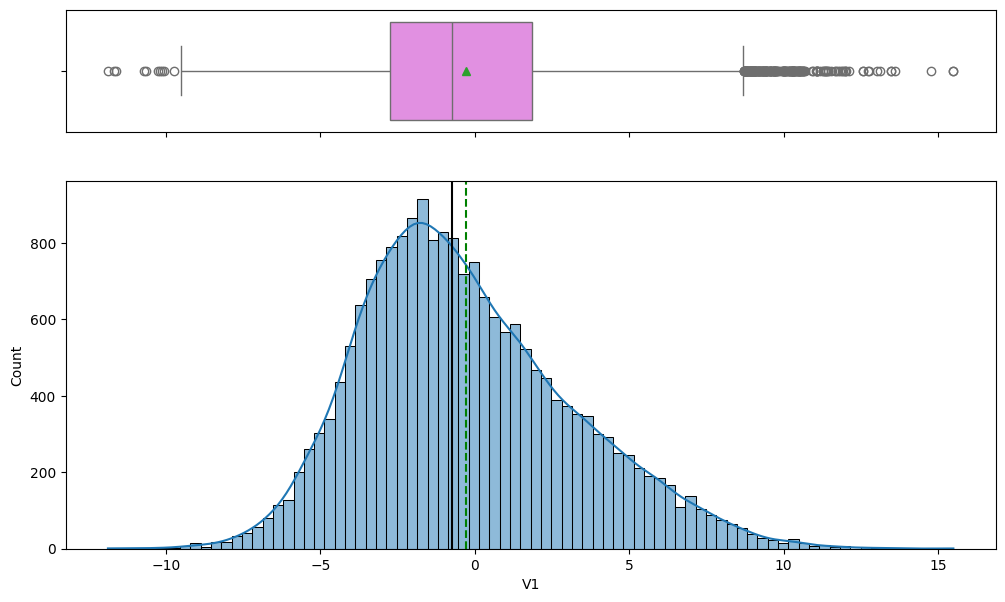

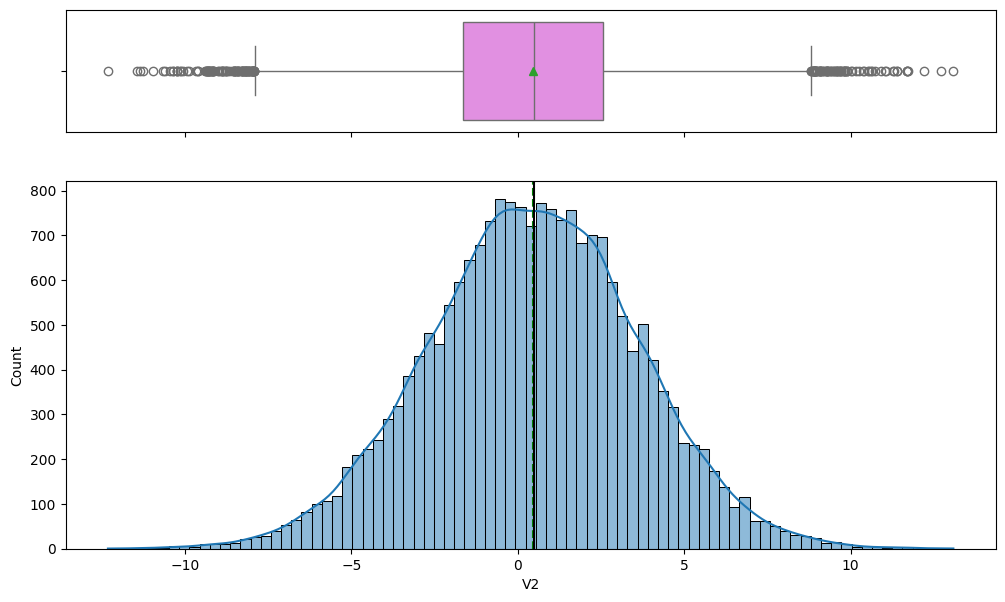

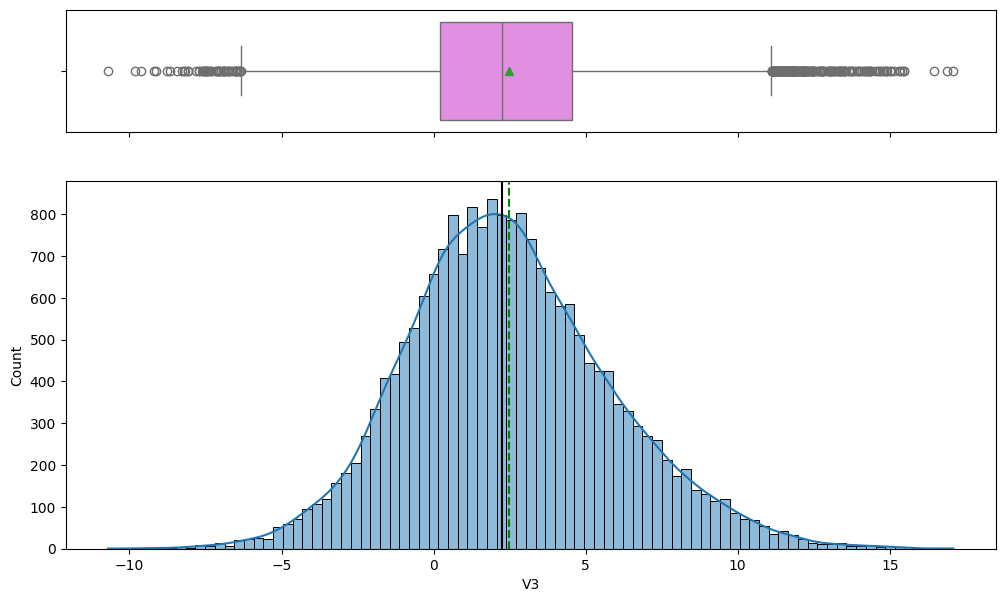

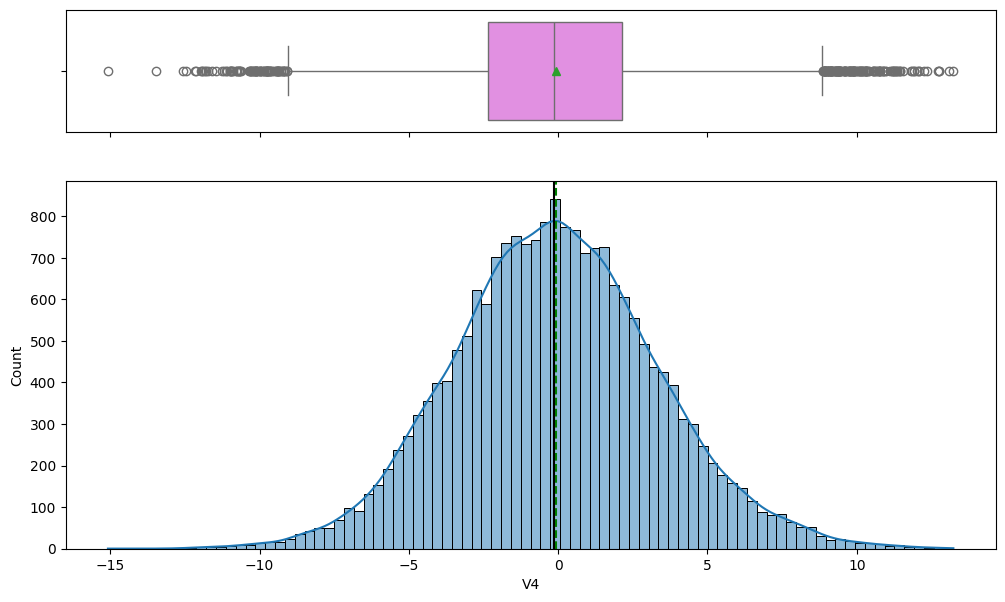

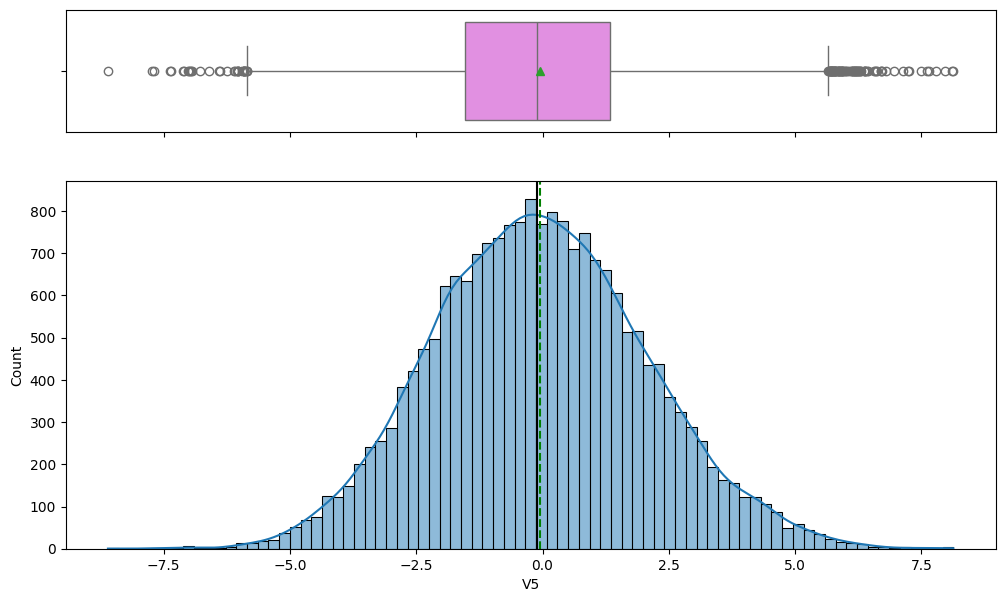

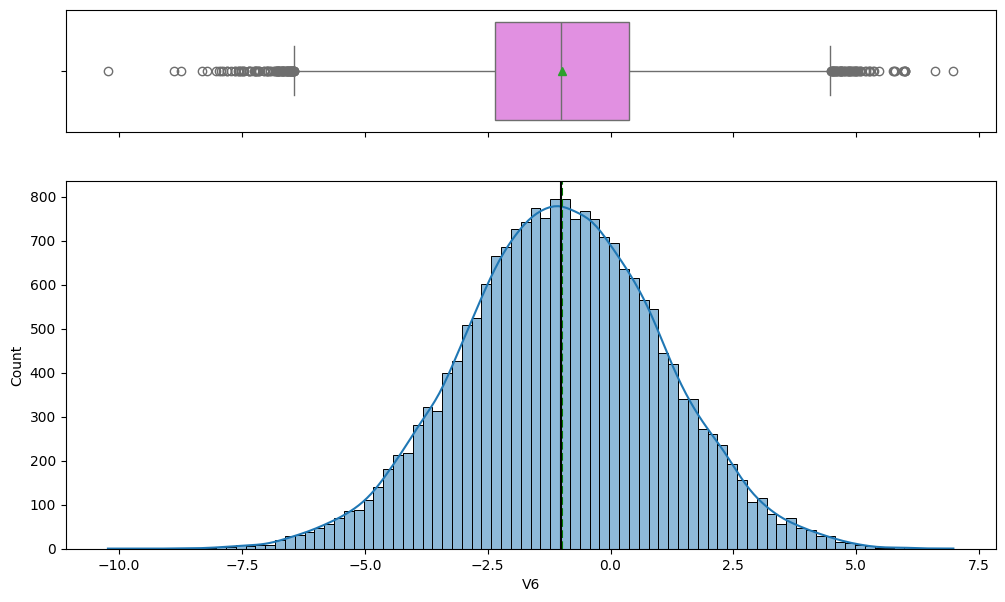

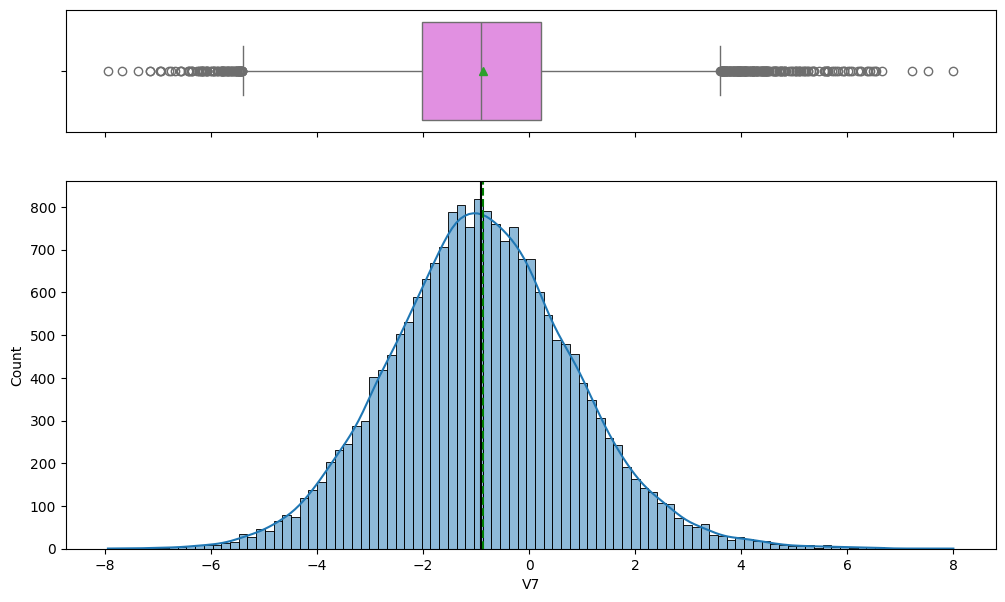

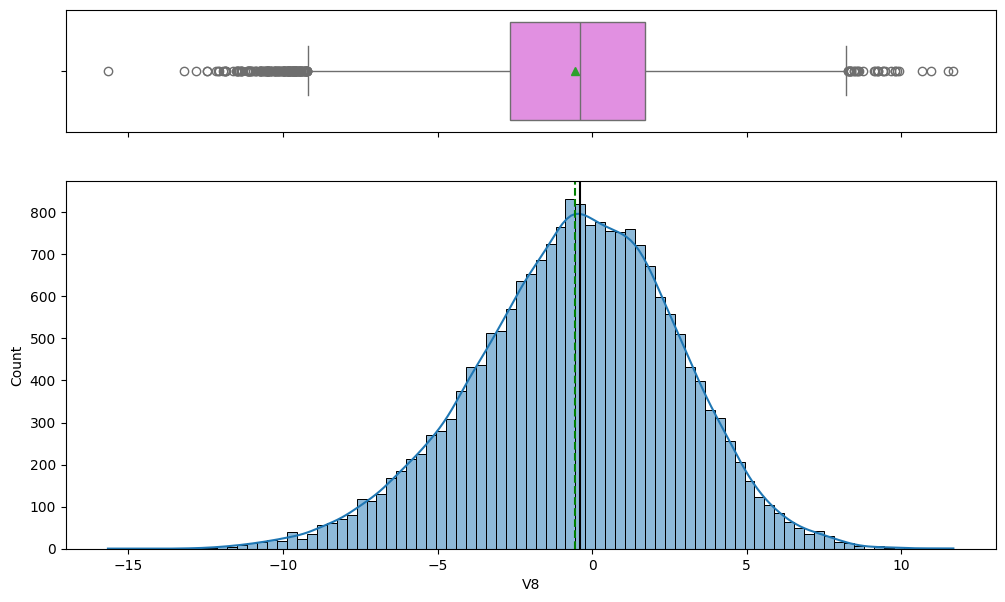

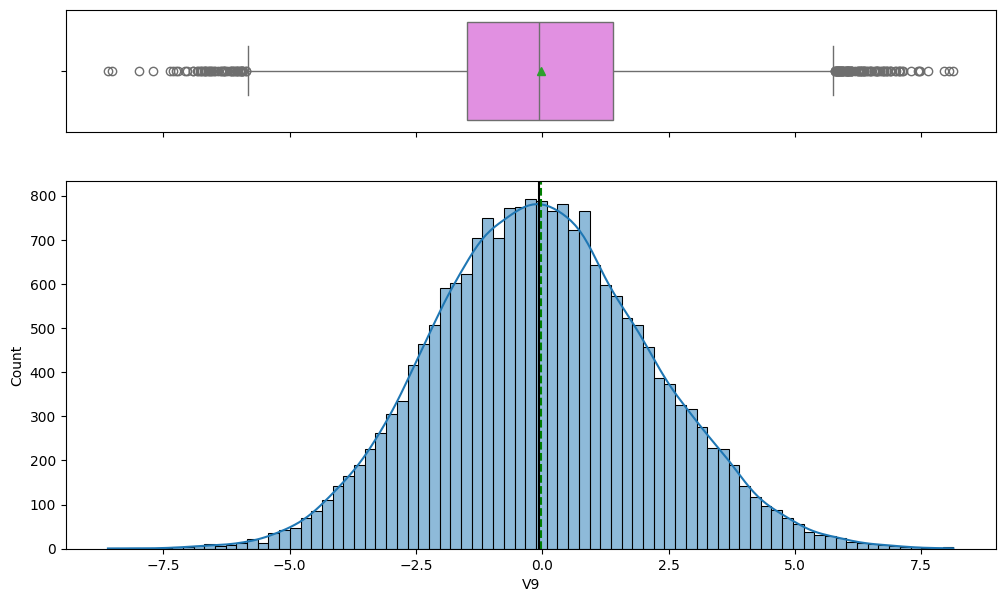

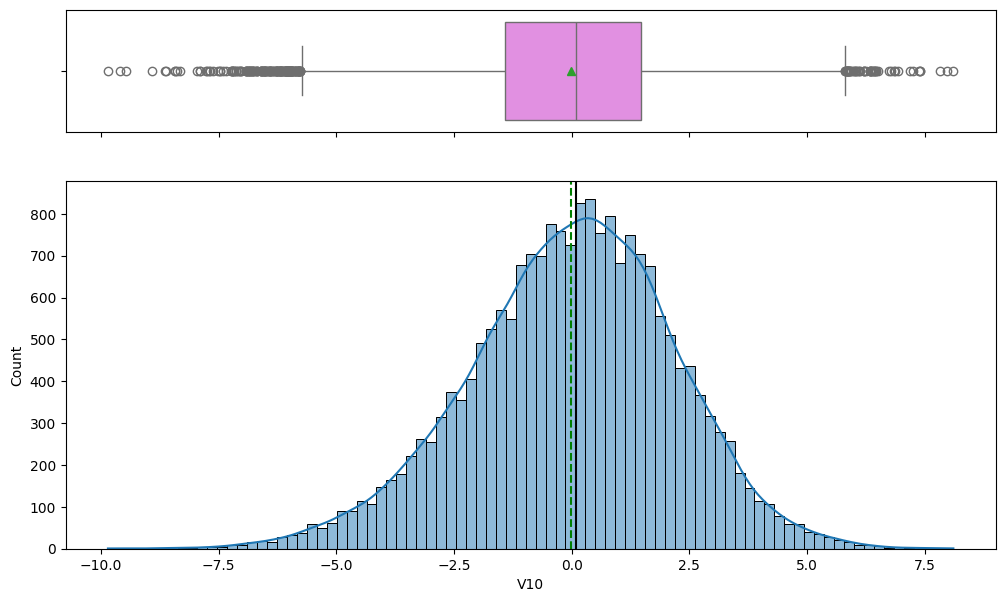

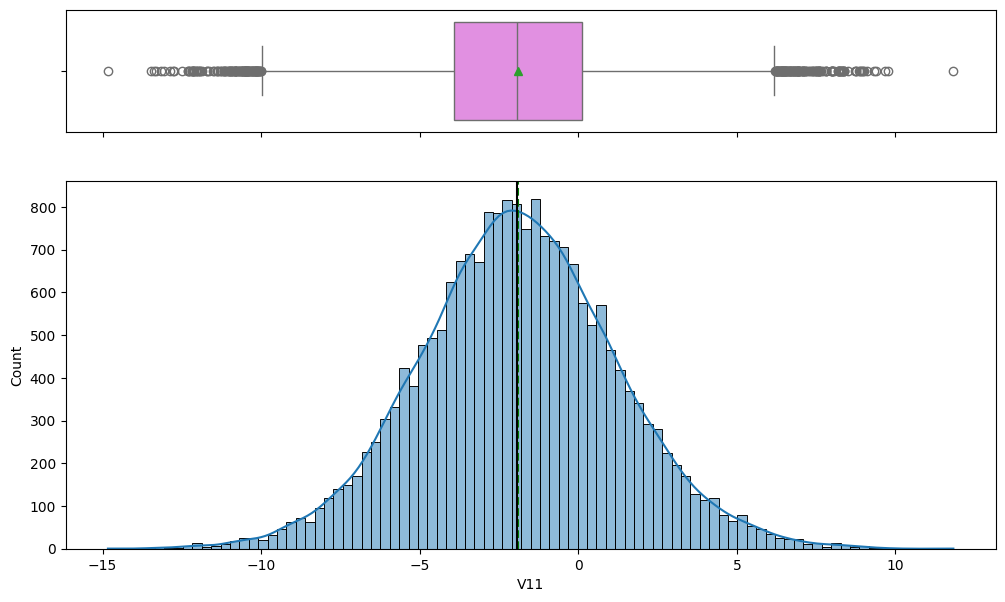

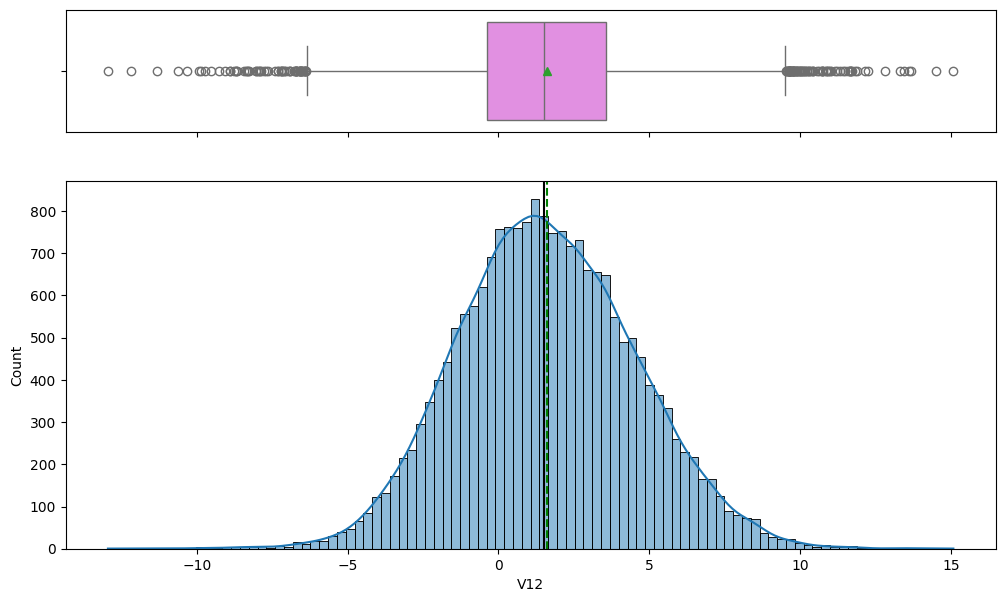

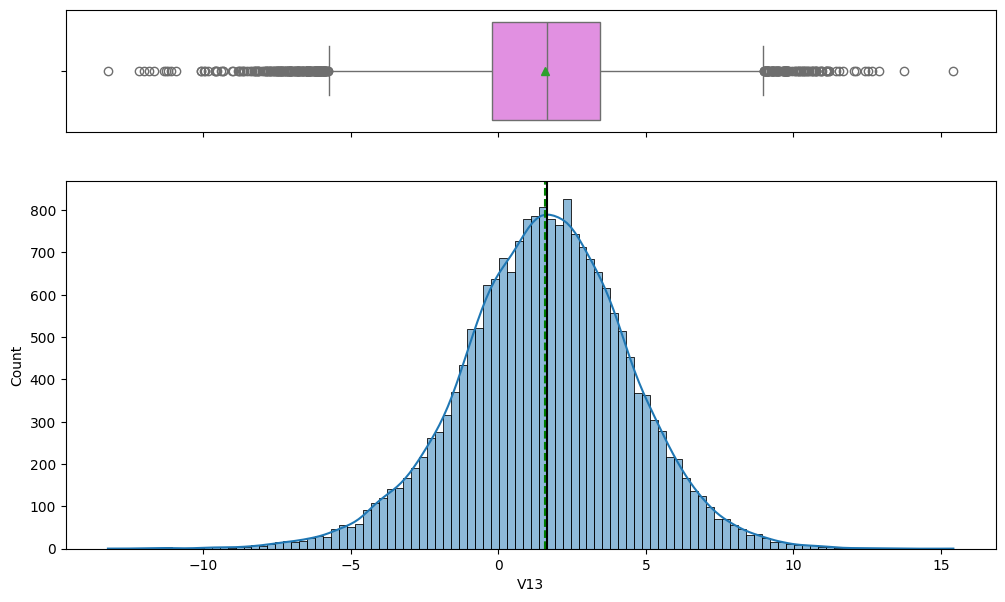

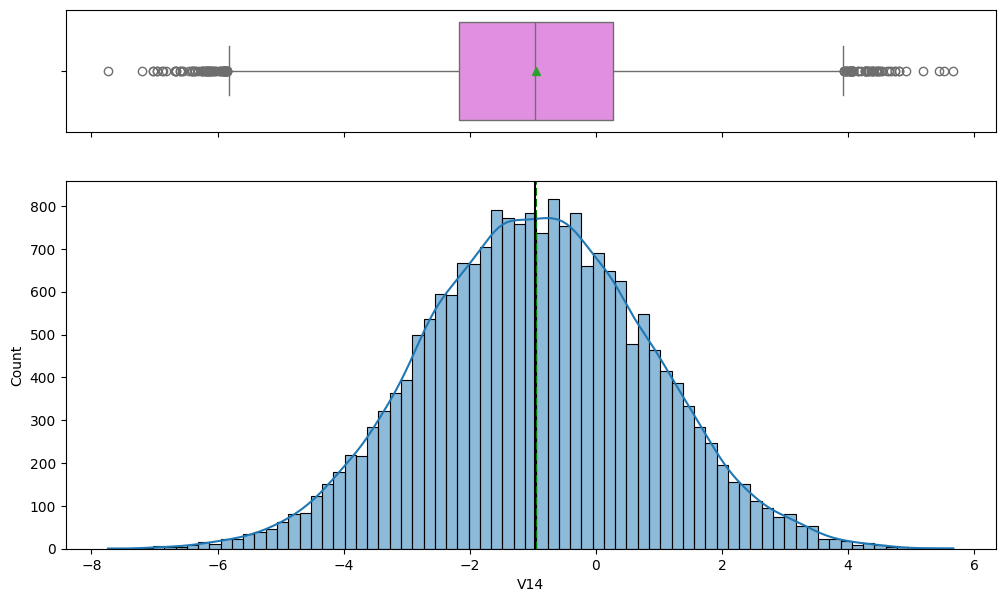

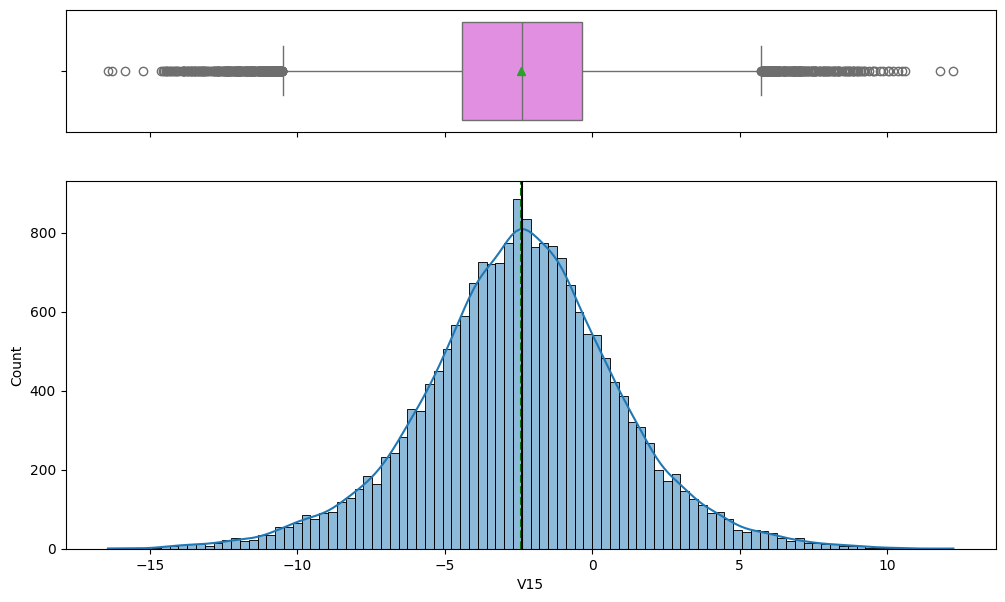

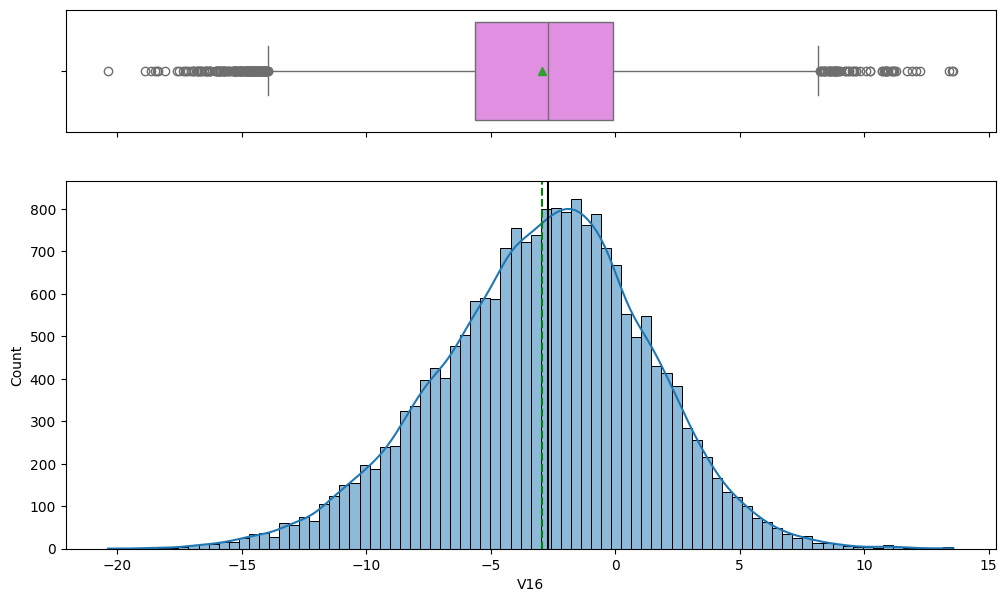

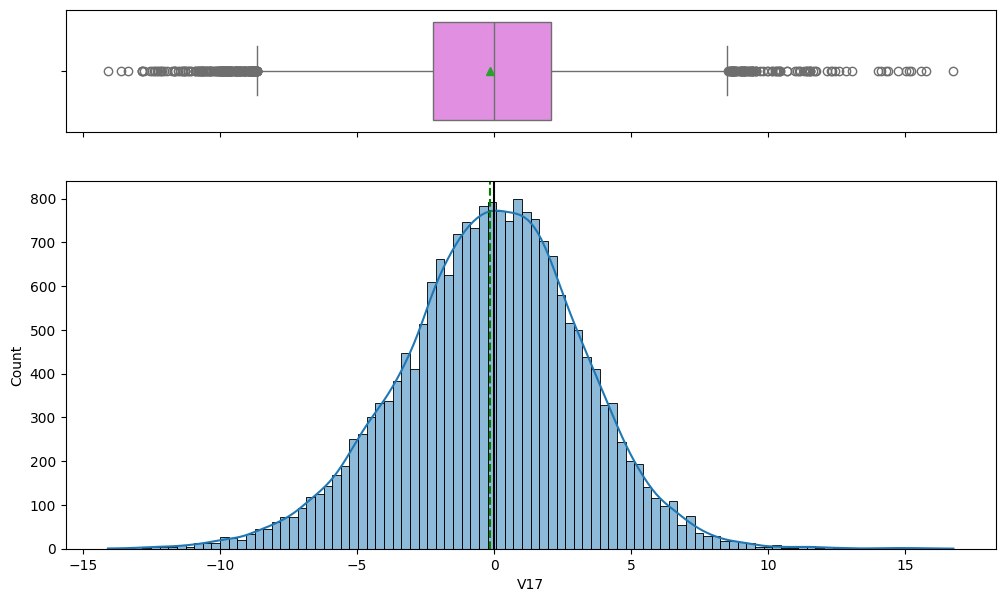

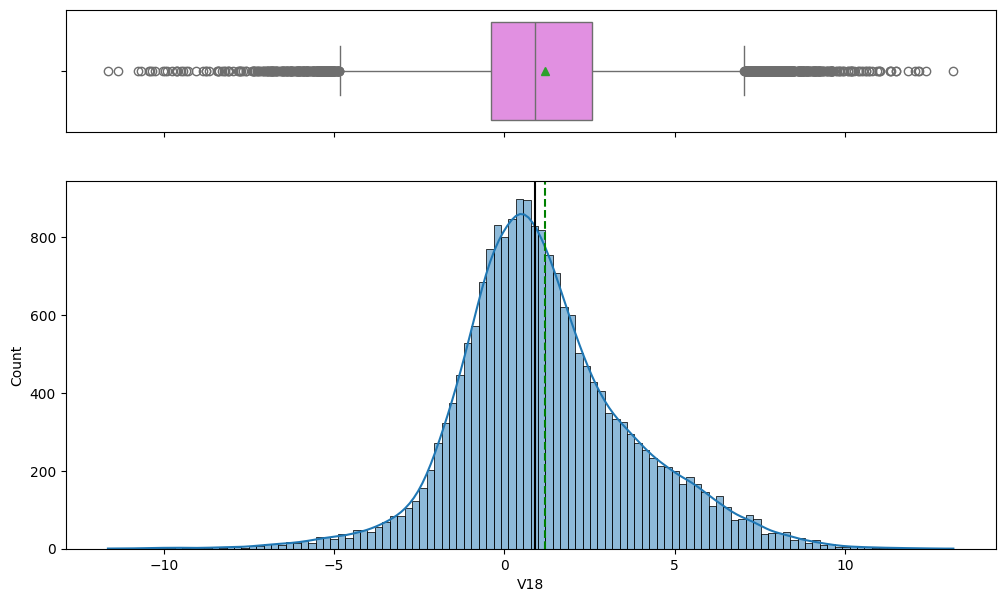

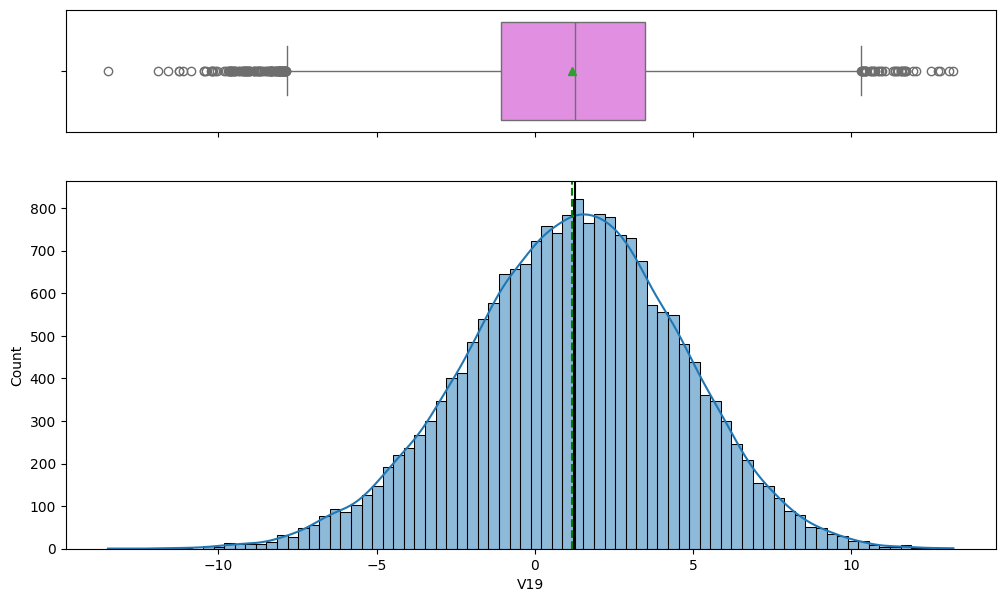

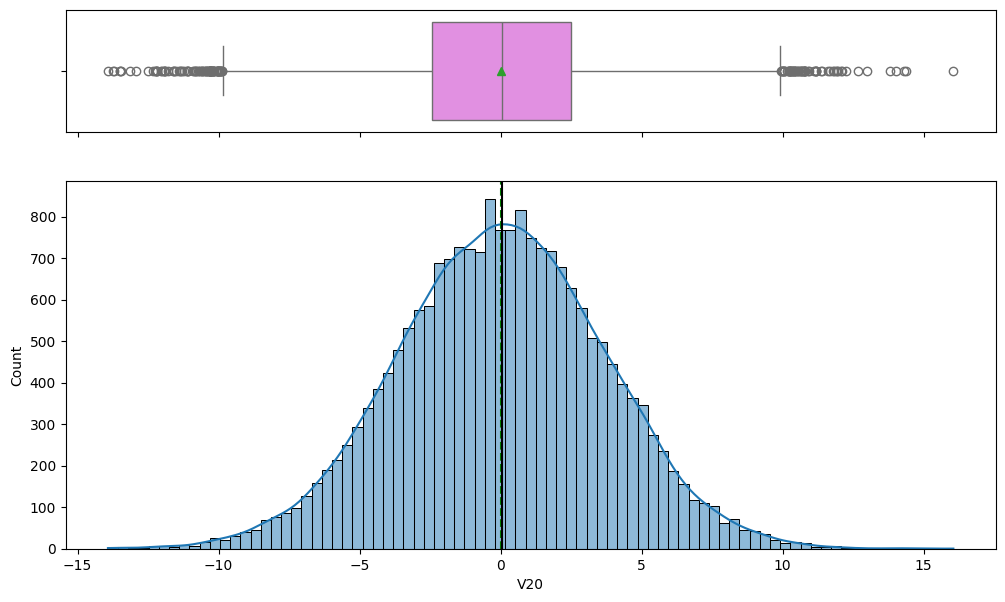

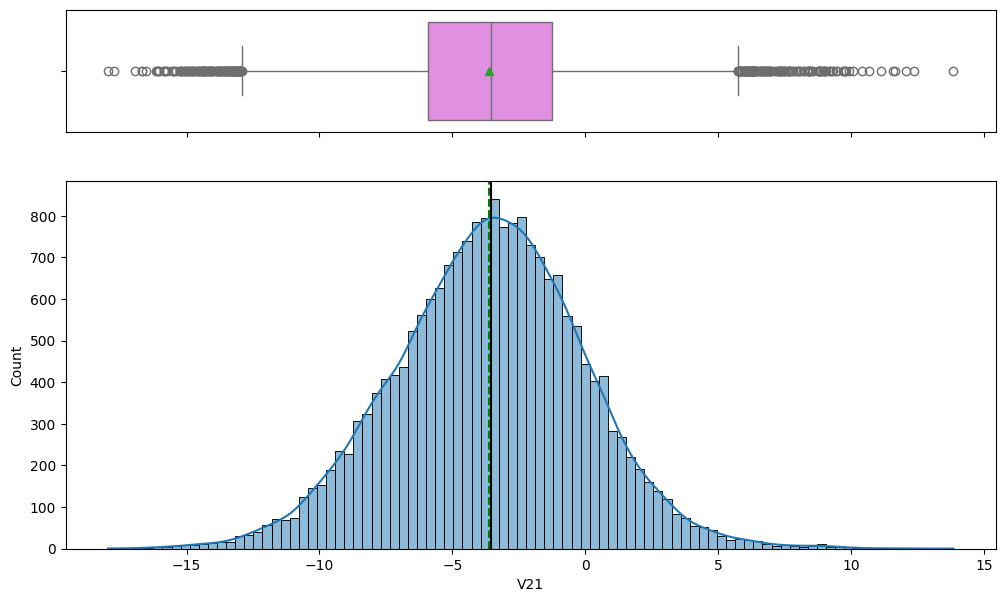

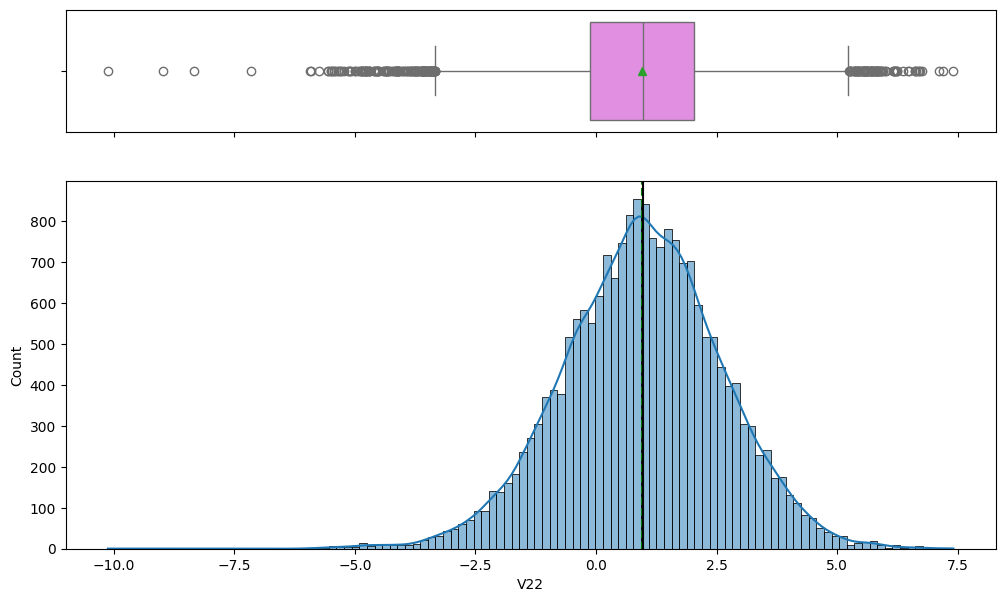

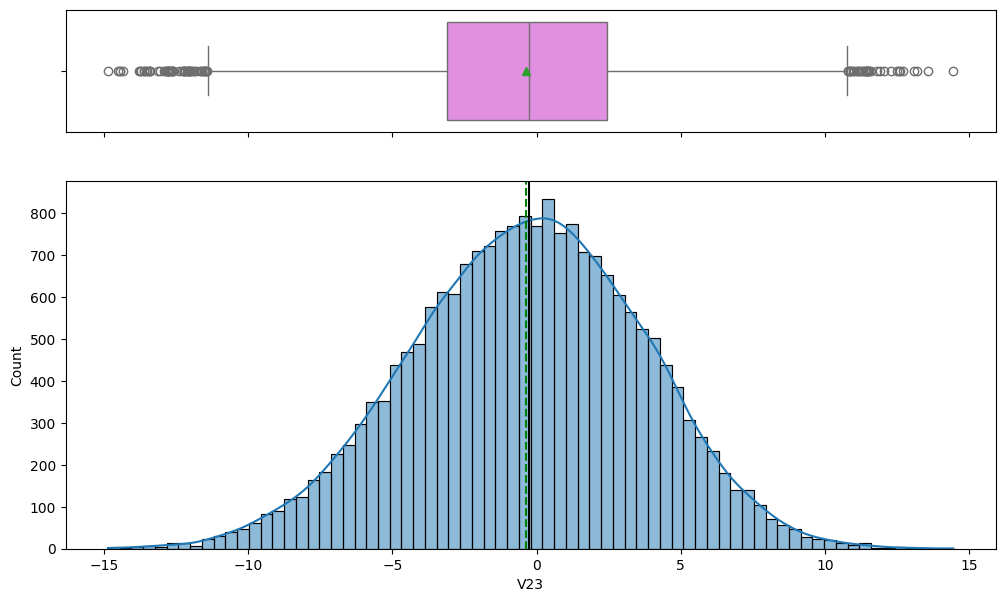

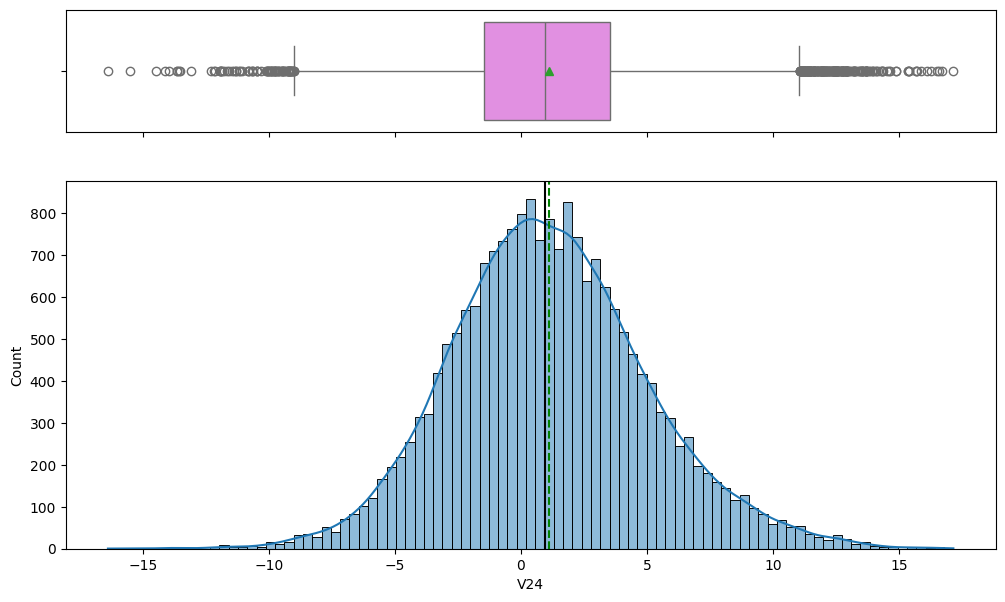

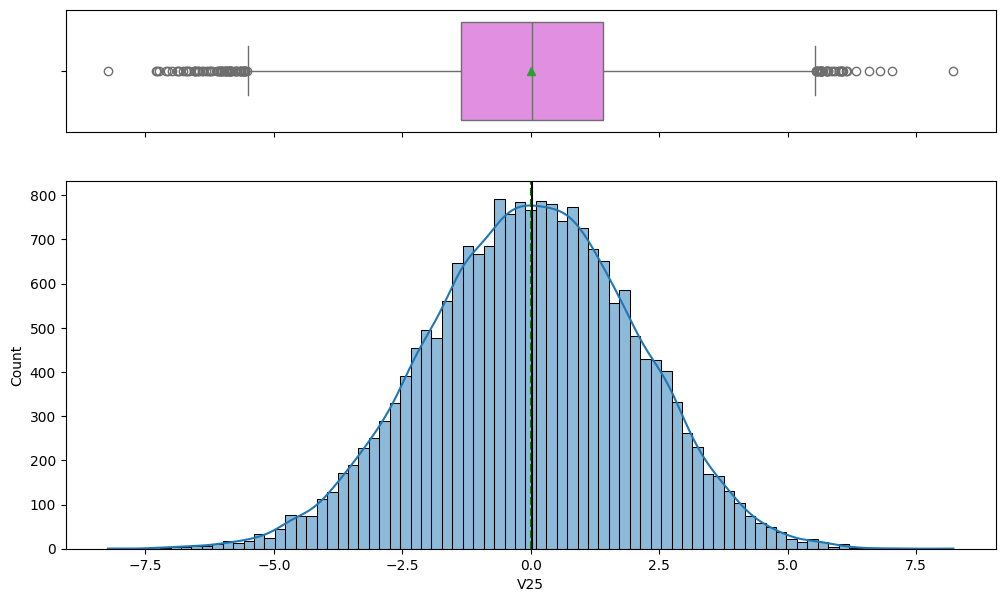

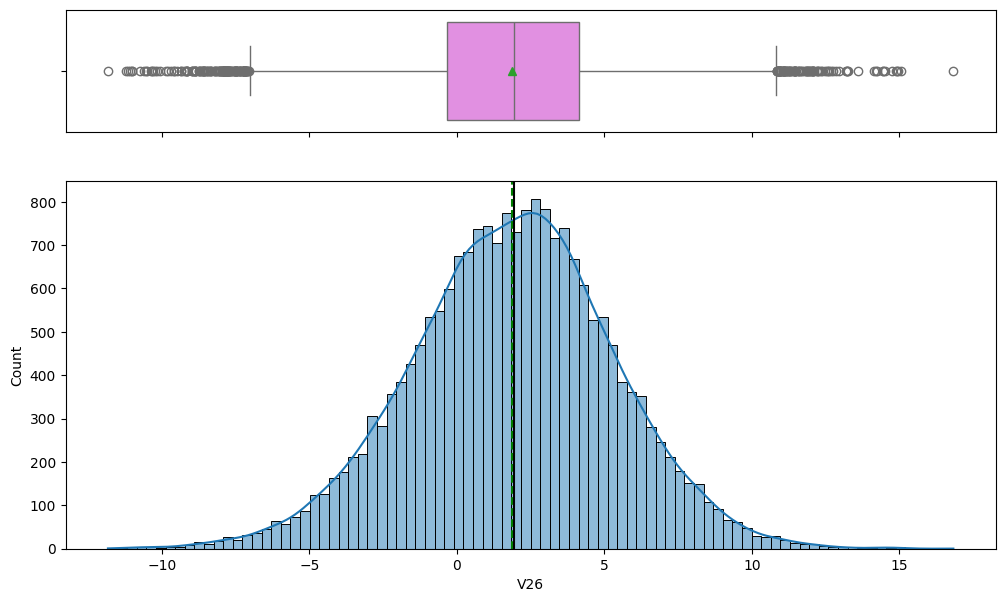

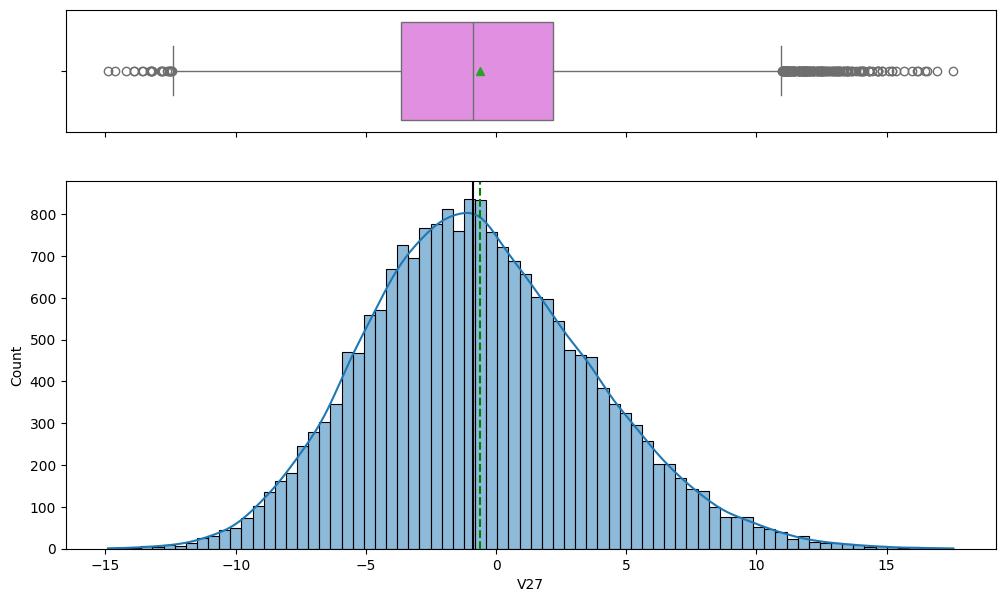

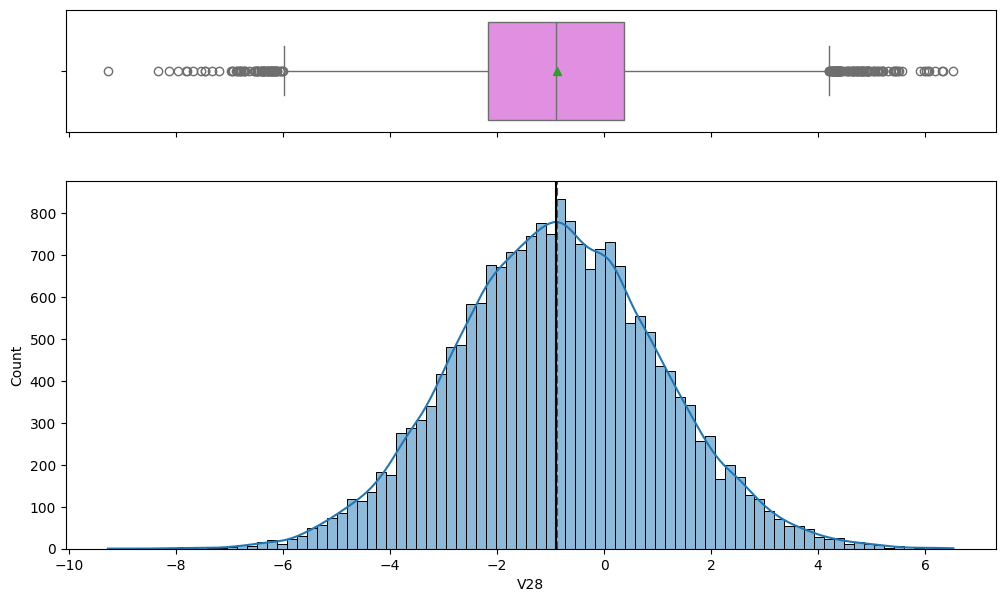

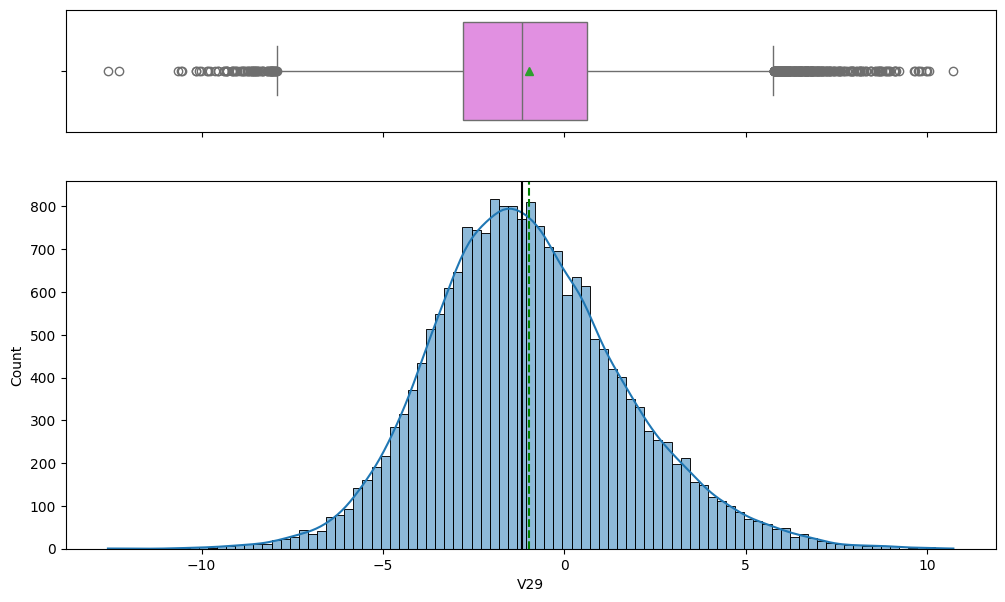

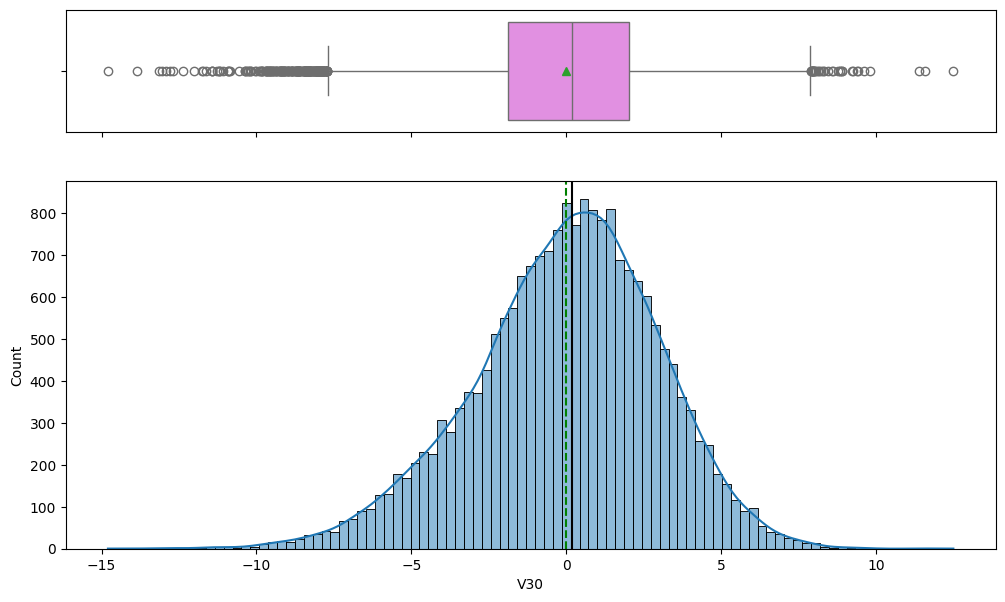

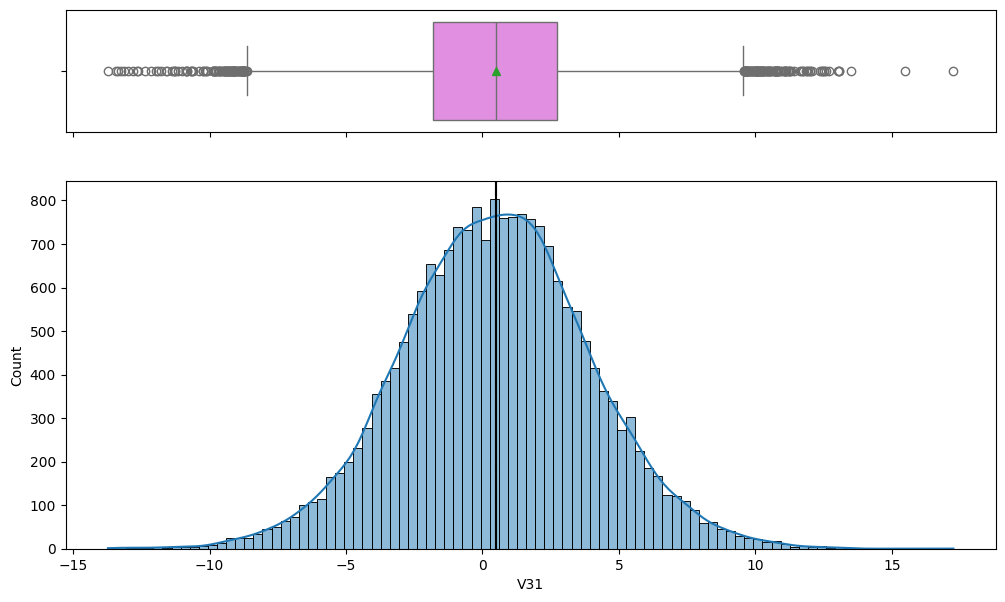

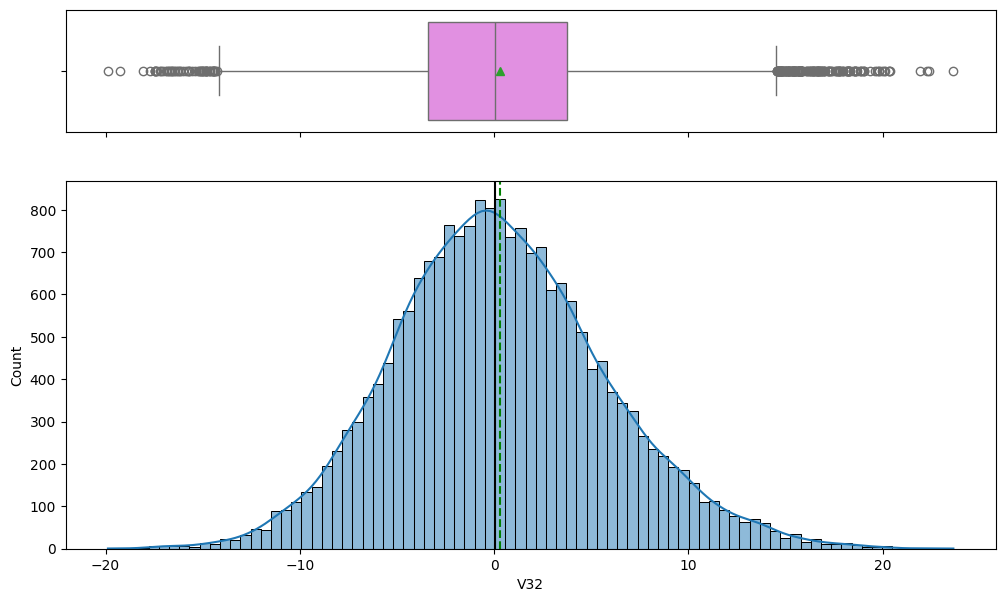

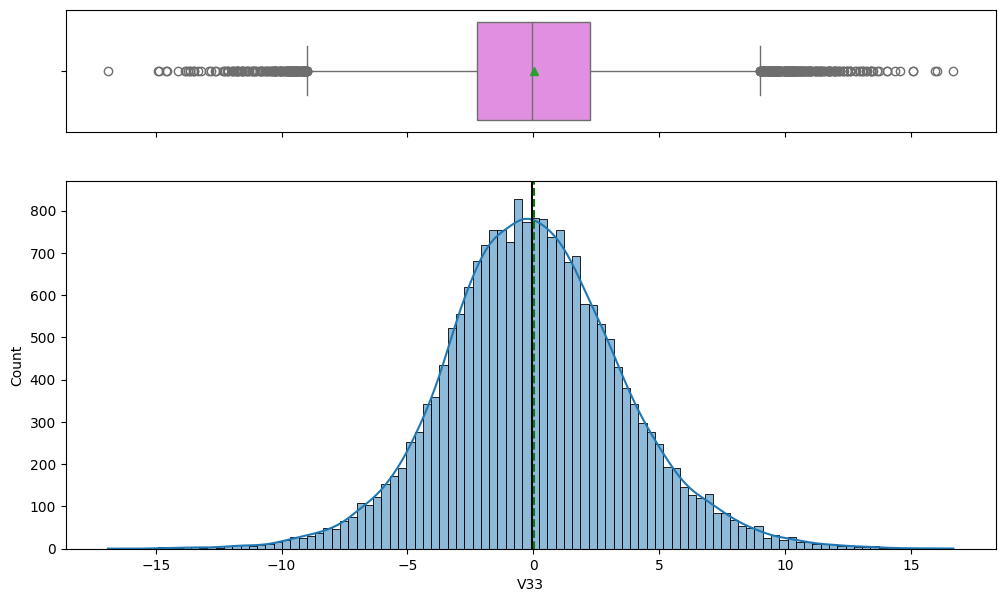

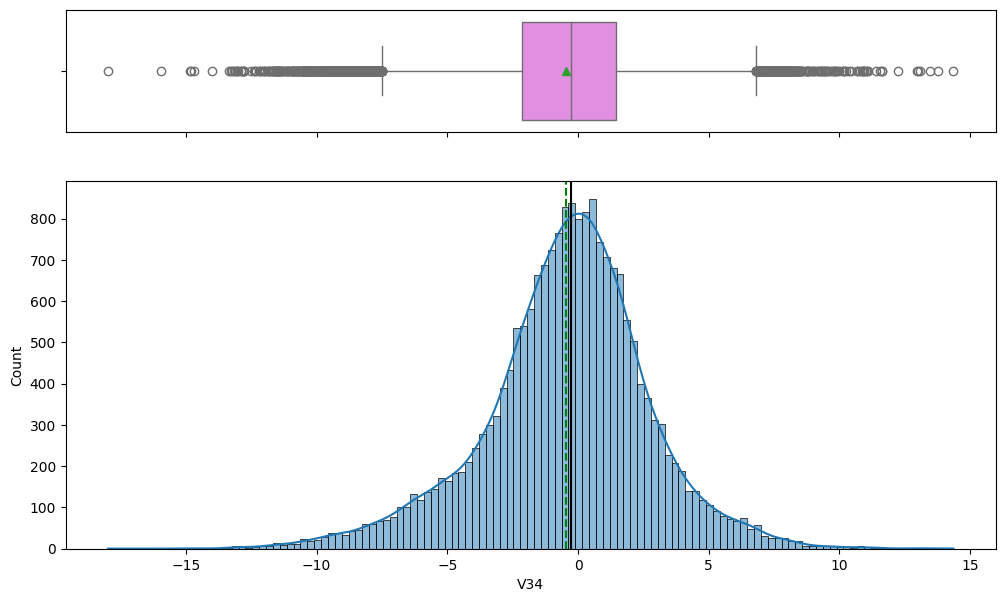

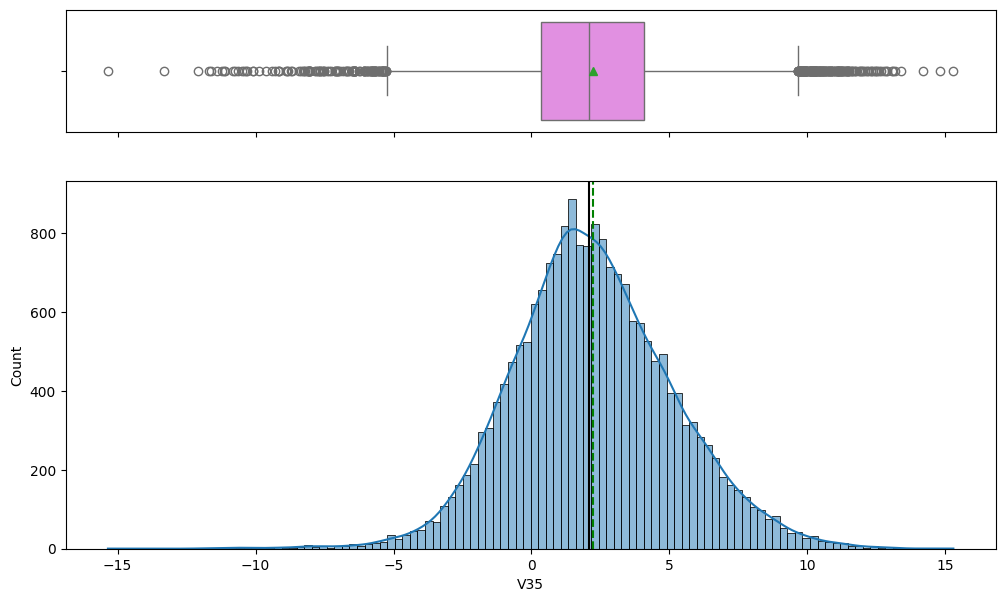

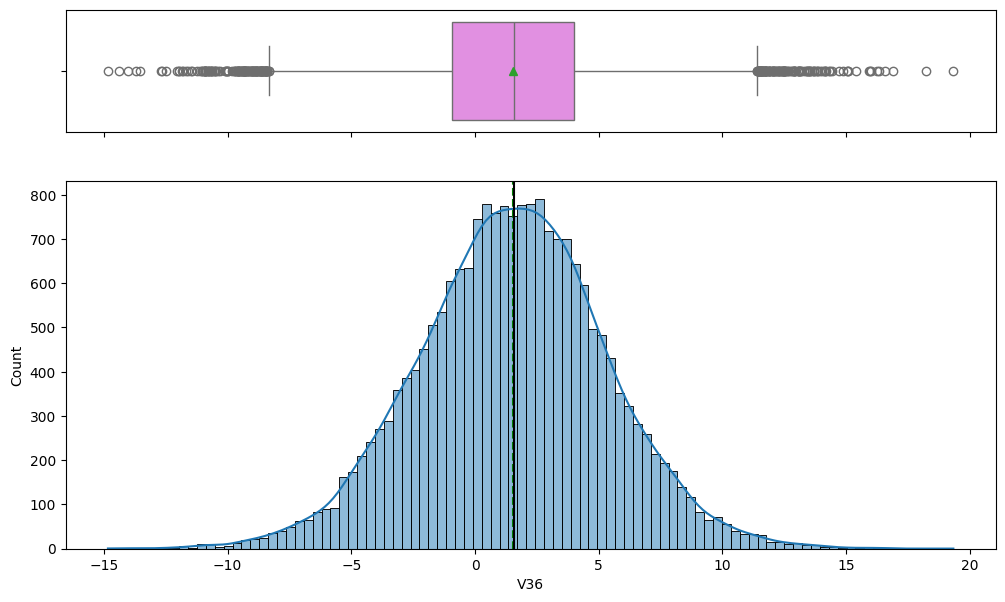

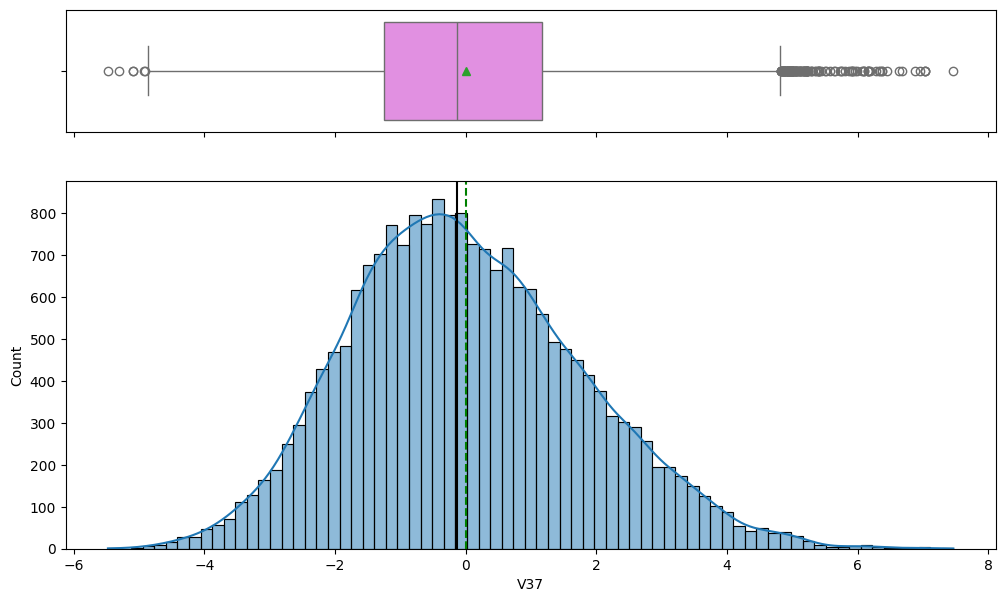

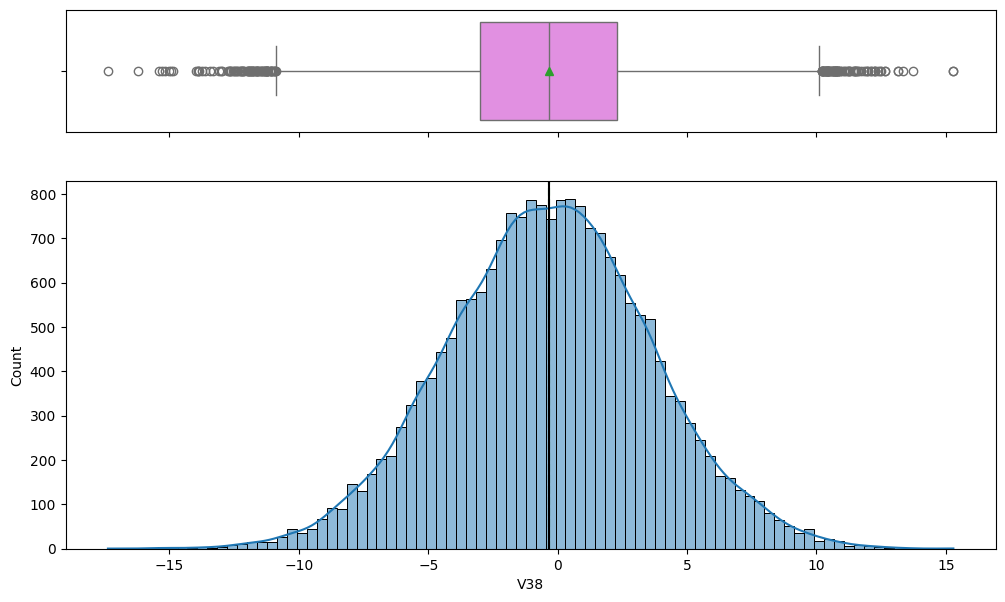

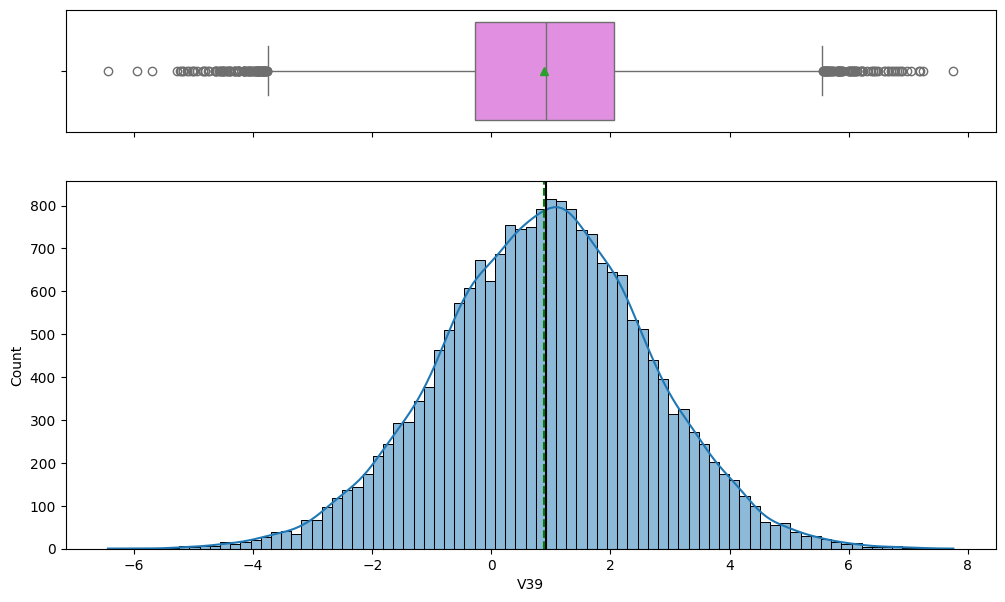

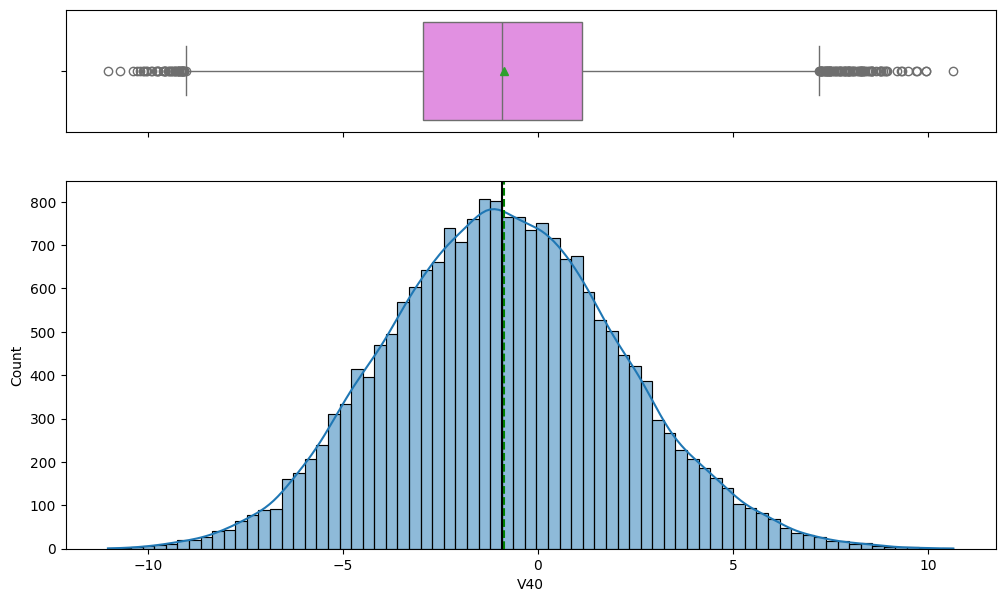

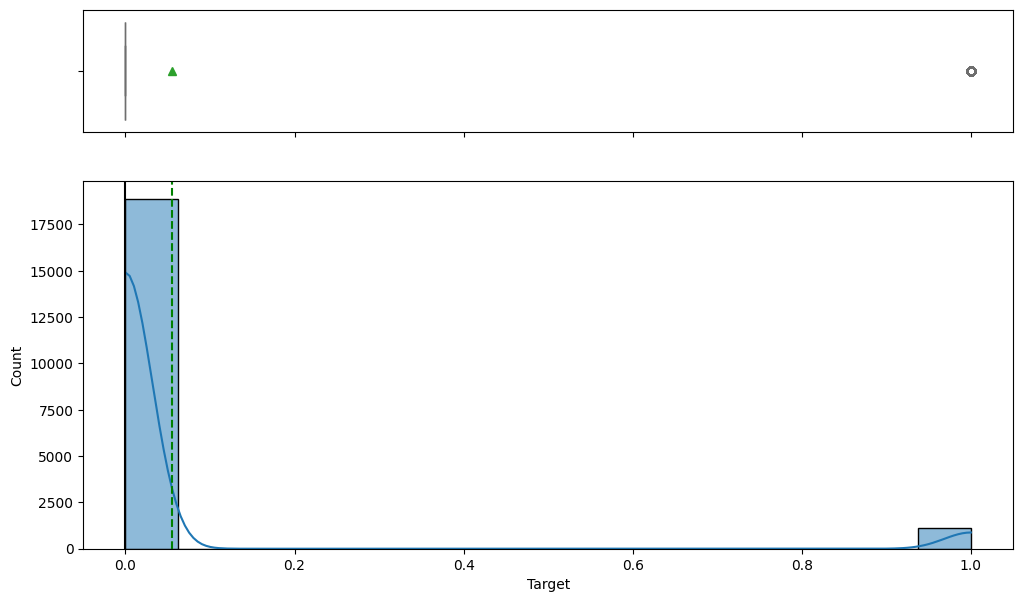

In [289]:
for feature in df.columns:
    histogram_boxplot(df, feature, figsize=(12, 7), kde=True, bins=None)



***Check distribution of Target***

In [290]:
df['Target'].value_counts()

,count
Target,
0,18890
1,1110


In [291]:
df['Target'].value_counts(normalize=True)

,proportion
Target,
0,0.9445
1,0.0555


## Bivariate Analysis

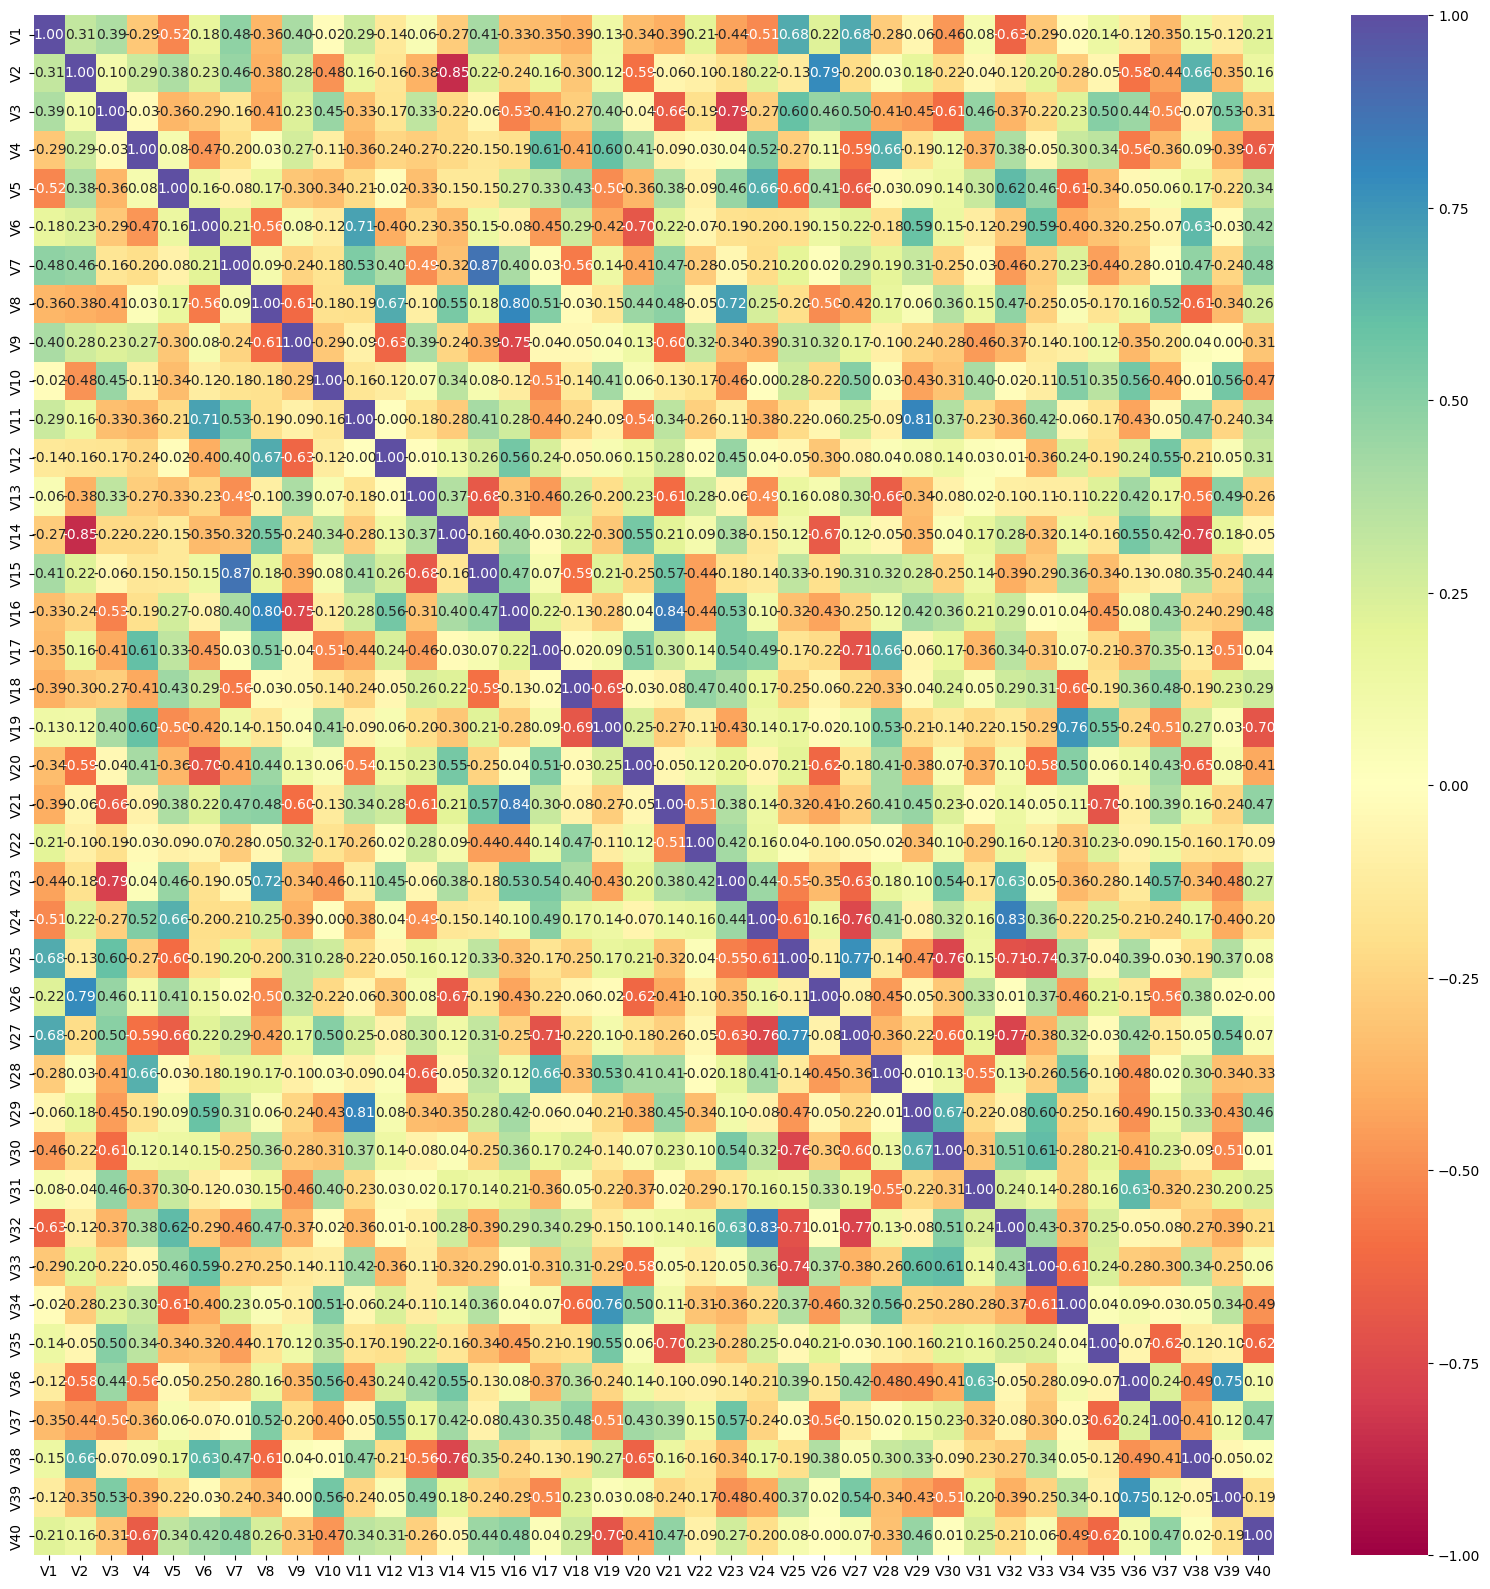

In [292]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()
cols_list.remove("Target")

plt.figure(figsize=(20, 20))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()

# **Data Preprocessing**

***Dropping Target variable***

In [293]:
#Dropping target variable
X = df.drop(["Target"], axis=1)
y = df["Target"]

***Splitting train dataset into training and validation set***

In [294]:
# Splitting train dataset into training and validation set. ratio 85:15
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=1, stratify=y)
print(X_train.shape,X_val.shape)

(17000, 40) (3000, 40)


***Preprocessing Test Dataset***

In [295]:
# Dividing test data into X_test and y_test
X_test = test_data.drop(["Target"], axis=1)
y_test = test_data["Target"]
print(X_test.shape)

(5000, 40)


***Impute missing value***

In [296]:
# Creating Simpleimputer
imputer = SimpleImputer(strategy="median")
#Replace the missing V1 and V2 values in the train, validation, and test sets. Avoiding leakage.
#Fit and transform the train data
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Transform the validation data
X_val = pd.DataFrame(imputer.transform(X_val), columns=X_train.columns)

# Transform the test data
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_train.columns)


***Checking for missing values***

In [297]:
# Checking that no column has missing values in train or test sets
print(X_train.isna().sum())
print("-" * 30)
print(X_val.isna().sum())
print("-" * 30)
print(X_test.isna().sum())

V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22    0
V23    0
V24    0
V25    0
V26    0
V27    0
V28    0
V29    0
V30    0
V31    0
V32    0
V33    0
V34    0
V35    0
V36    0
V37    0
V38    0
V39    0
V40    0
dtype: int64
------------------------------
V1     0
V2     0
V3     0
V4     0
V5     0
V6     0
V7     0
V8     0
V9     0
V10    0
V11    0
V12    0
V13    0
V14    0
V15    0
V16    0
V17    0
V18    0
V19    0
V20    0
V21    0
V22

***Convert to Numpy Array***

In [298]:
y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

# **Model Building**

## Model Evaluation Criterion

***Possible Errors***

In predicting maintainance schedule, the model can make the following errors


*   False negatives (FN) are real failures in a generator where there is no detection by model.
*   False positives (FP) are failure detections in a generator where there is no failure.



***Which criteria is more important?***



*   Predicting maintainance is not needed when its needed can lead to reduced uptime, increased maintainance cost and time needed for maintainance which directly contradicts the business objective so this would be the criteria to improve
*   False positives will lead to maintainance being done when not needed, though not ideal and lead to increased costs it is not the main objective
*   To minimize missed maintainance needs, the company needs to ***Maximize Recall***. Higher recall ensures most of the maintainance requests are caught.



# **Utility functions**

In [299]:
def plot(history, name):
    """
    Function to plot loss/accuracy

    history: an object which stores the metrics and losses.
    name: can be one of Loss or Accuracy
    """
    fig, ax = plt.subplots() #Creating a subplot with figure and axes.
    plt.plot(history.history[name]) #Plotting the train accuracy or train loss
    plt.plot(history.history['val_'+name]) #Plotting the validation accuracy or validation loss

    plt.title('Model ' + name.capitalize()) #Defining the title of the plot.
    plt.ylabel(name.capitalize()) #Capitalizing the first letter.
    plt.xlabel('Epoch') #Defining the label for the x-axis.
    fig.legend(['Train', 'Validation'], loc="outside right upper") #Defining the legend, loc controls the position of the legend.

***Create a dataframe to store the results from all the models we build***

In [300]:
# Create a blank DataFrame to store the training and validation evaluation results of different models.

evaluation_results = pd.DataFrame(columns=['Model', '# hidden layers', '# neurons hidden layer', 'activation function hidden layer', 'configuration', '# epochs', 'batch size', 'Train_Loss', 'Train_Accuracy', 'Train_Precision', 'Train_Recall', 'Train_F1',
                                         'Val_Loss', 'Val_Accuracy', 'Val_Precision', 'Val_Recall', 'Val_F1'])

In [301]:
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1


## Initial Model Building (Model 0)

We build this baseline neural network model using a simple architecture:

* ***Input Layer***: The input shape is determined by the number of features in the training data, X_train​.
* ***Hidden Layers***: We use one hidden layer, with 7 neuron with ReLU activation function.
*  ***Output Layer***: One Dense layer with 1 unit and a sigmoid activation to handle binary classification.

***Loss Function***: We use Binary Crossentropy as the loss function, which is standard for binary classification problems.

***Optimizer***: We use Stochastic Gradient Descent (SGD) as the optimizer to adjust the network's weights during training.

***Metrics***: The model is evaluated using the Recall metric.

The model is trained for 50 epochs, with a batch size of 64.

In [302]:
# Clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [303]:
#Initializing the neural network
model0 = Sequential()

model0.add(Dense(7, activation='relu', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model0.add(Dense(1, activation='sigmoid'))                    # Output Layer

In [304]:
#Printing the summary
model0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           287 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [305]:
optimizer = 'sgd'   # Defining SGD as the optimizer to be used
loss = 'binary_crossentropy'   # Defining binary crossentropy as the loss function

#Compiling the model.
model0.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [306]:
epochs = 50   # Training the model for 25 epochs
batch_size = 64    # Setting the batch size equal to the number of rows

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
start = time.time()

# Fitting the model.
history0 = model0.fit(X_train, y_train,
                      validation_data=(X_val,y_val) ,
                      batch_size=batch_size,
                      epochs=epochs)

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - binary_accuracy: 0.9085 - loss: 0.2491 - precision: 0.3386 - recall: 0.6808 - val_binary_accuracy: 0.9687 - val_loss: 0.1272 - val_precision: 0.7417 - val_recall: 0.6707
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9657 - loss: 0.1318 - precision: 0.7290 - recall: 0.6076 - val_binary_accuracy: 0.9743 - val_loss: 0.1101 - val_precision: 0.8309 - val_recall: 0.6766
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9706 - loss: 0.1163 - precision: 0.8075 - recall: 0.6182 - val_binary_accuracy: 0.9760 - val_loss: 0.1019 - val_precision: 0.8467 - val_recall: 0.6946
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9729 - loss: 0.1078 - precision: 0.8375 - recall: 0.6341 - val_binary_accuracy: 0.9767 - val_loss: 0.0972 - val_precision: 0.8392 - val_recall: 0.7186
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9742 - loss: 0.1021 - precision

In [307]:
print("Time taken in seconds ",end-start)

Time taken in seconds  41.229082345962524


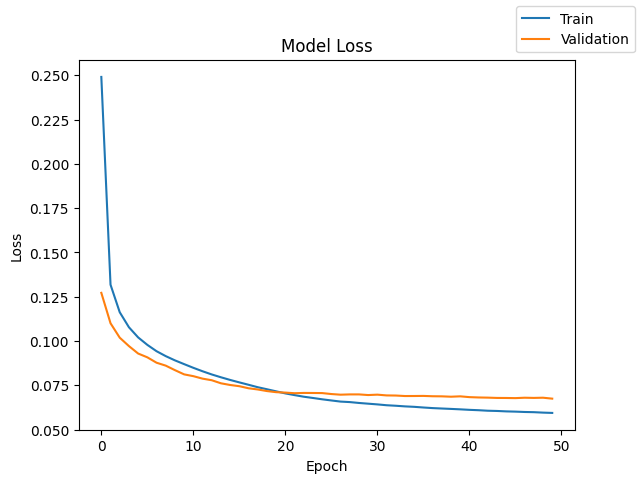

In [308]:
plot(history0,'loss')

In [309]:
evaluation_results.loc[0] = ['Model 0', '1', '[7]', 'ReLU', 'baseline', epochs, batch_size, history0.history["loss"][-1], history0.history["binary_accuracy"][-1], history0.history["precision"][-1], history0.history["recall"][-1], 2 * (history0.history["precision"][-1] * history0.history["recall"][-1]) / (history0.history["precision"][-1] + history0.history["recall"][-1] + 1e-7), history0.history["val_loss"][-1], history0.history["val_binary_accuracy"][-1], history0.history["val_precision"][-1], history0.history["val_recall"][-1], 2 * (history0.history["val_precision"][-1] * history0.history["val_recall"][-1]) / (history0.history["val_precision"][-1] + history0.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.93662,0.796407,0.860841


***Observations***
* A single hidden layer with 7 neurons is surprisingly effective for accuracy, but it struggles with the minority class
* This model is too "simple" to capture the complex patterns of Class 1. While a 0.86 F1-score is a good start, the recall of 0.79 suggests it's missing over 20% of the targets we actually care about

# **Model Performance Improvement**

---



## Model 1

***Lets add another layer to see if we can improve model performance***

We built our second neural network model with the following changes:


*   Additional hidden layer with 14 neurons



In [310]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [311]:
#Initializing the neural network
model1 = Sequential()

model1.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],))) # Hidden Layer 1
model1.add(Dense(7, activation='relu'))                       # Hidden Layer 2
model1.add(Dense(1, activation='sigmoid'))                    # Output Layer

In [312]:
#Printing the summary
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [313]:
optimizer = 'sgd'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'   # defining binary crossentropy as the loss function

#Compiling the model.
model1.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [314]:
epochs = 50   # training the model for 25 epochs
batch_size = 64    # setting the batch size equal to the number of rows

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
start = time.time()

# Fitting the model.
history1 = model1.fit(X_train, y_train,
                      validation_data=(X_val,y_val) ,
                      batch_size=batch_size,
                      epochs=epochs)

# time.time() returns the time in seconds since Thu Jan 1 00:00:00 1970.
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9431 - loss: 0.1802 - precision: 0.4828 - recall: 0.3563 - val_binary_accuracy: 0.9700 - val_loss: 0.1116 - val_precision: 0.8348 - val_recall: 0.5749
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9702 - loss: 0.1106 - precision: 0.8494 - recall: 0.5620 - val_binary_accuracy: 0.9770 - val_loss: 0.0976 - val_precision: 0.8657 - val_recall: 0.6946
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9756 - loss: 0.0979 - precision: 0.8895 - recall: 0.6405 - val_binary_accuracy: 0.9790 - val_loss: 0.0897 - val_precision: 0.8881 - val_recall: 0.7126
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9789 - loss: 0.0896 - precision: 0.9148 - recall: 0.6829 - val_binary_accuracy: 0.9810 - val_loss: 0.0829 - val_precision: 0.9104 - val_recall: 0.7305
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - binary_accuracy: 0.9804 - loss: 0.0835 - precision

In [315]:
print("Time taken in seconds ",end-start)

Time taken in seconds  42.26356887817383


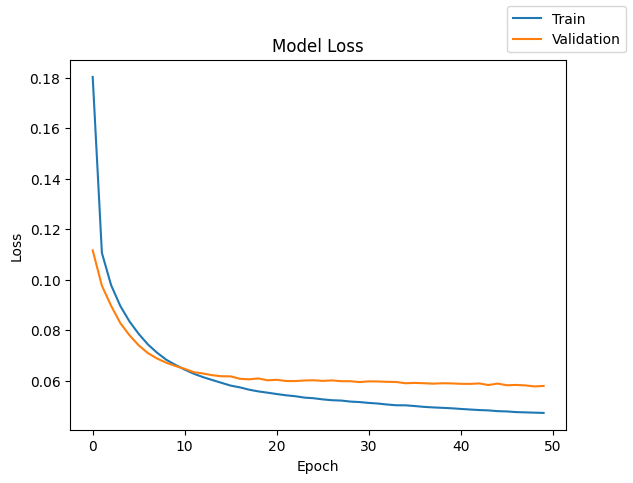

In [316]:
plot(history1,'loss')

In [317]:
evaluation_results.loc[1] = ['Model 1', '2', '[14, 7]', 'ReLU', '2 hidden layers', epochs, batch_size, history1.history["loss"][-1], history1.history["binary_accuracy"][-1], history1.history["precision"][-1], history1.history["recall"][-1], 2 * (history1.history["precision"][-1] * history1.history["recall"][-1]) / (history1.history["precision"][-1] + history1.history["recall"][-1] + 1e-7), history1.history["val_loss"][-1], history1.history["val_binary_accuracy"][-1], history1.history["val_precision"][-1], history1.history["val_recall"][-1], 2 * (history1.history["val_precision"][-1] * history1.history["val_recall"][-1]) / (history1.history["val_precision"][-1] + history1.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026


***Observations***
* Moving to 2 layers [14, 7] immediately improved the model's ability to "see" Class 1
* Increasing the capacity of the network allowed it to learn more complex decision boundaries. This led to a nearly 3 % jump in F1-score, proving that the extra layer was worth the minor increase in computational cost

## Model 2

***Using Adam Optimizer***

We built our third neural network model with the following changes:

Use of Adam as the optimizer to automatically adjust the learning rate for each weight.

In [318]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [319]:
#Initializing the neural network
model2 = Sequential()
model2.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model2.add(Dense(7, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

In [320]:
model2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [321]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model2.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [322]:
epochs = 50
batch_size = 64

start = time.time()
history2 = model2.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - binary_accuracy: 0.5018 - loss: 1.1182 - precision: 0.0893 - recall: 0.8674 - val_binary_accuracy: 0.9193 - val_loss: 0.6091 - val_precision: 0.3824 - val_recall: 0.7305
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9579 - loss: 0.5607 - precision: 0.6268 - recall: 0.5949 - val_binary_accuracy: 0.9743 - val_loss: 0.5137 - val_precision: 0.8814 - val_recall: 0.6228
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9723 - loss: 0.4772 - precision: 0.8587 - recall: 0.5992 - val_binary_accuracy: 0.9783 - val_loss: 0.4384 - val_precision: 0.9180 - val_recall: 0.6707
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9763 - loss: 0.4076 - precision: 0.9079 - recall: 0.6373 - val_binary_accuracy: 0.9803 - val_loss: 0.3758 - val_precision: 0.9030 - val_recall: 0.7246
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9782 - loss: 0.3502 - precision

In [323]:
print("Time taken in seconds ",end-start)

Time taken in seconds  46.88948702812195


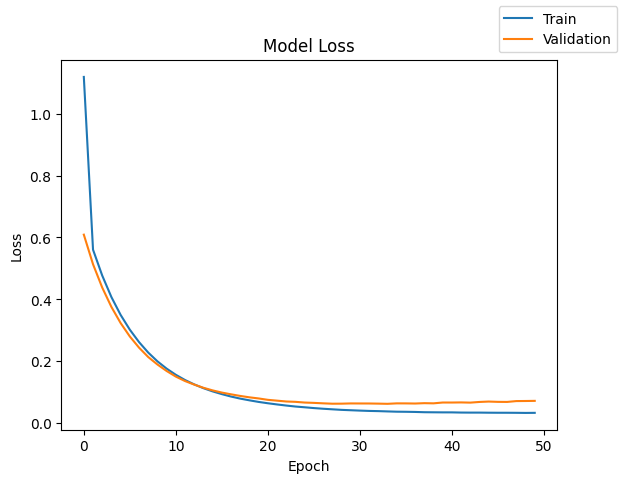

In [324]:
plot(history2,'loss')

In [325]:
evaluation_results.loc[2] = ['Model 2', '2', '[14, 7]', 'ReLU', 'optimizer=adam', epochs, batch_size, history2.history["loss"][-1], history2.history["binary_accuracy"][-1], history2.history["precision"][-1], history2.history["recall"][-1], 2 * (history2.history["precision"][-1] * history2.history["recall"][-1]) / (history2.history["precision"][-1] + history2.history["recall"][-1] + 1e-7), history2.history["val_loss"][-1], history2.history["val_binary_accuracy"][-1], history2.history["val_precision"][-1], history2.history["val_recall"][-1], 2 * (history2.history["val_precision"][-1] * history2.history["val_recall"][-1]) / (history2.history["val_precision"][-1] + history2.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630


***Observations***
* Switching the optimizer was the single most impactful change
* Adam’s adaptive learning rate is far superior for this dataset. It achieved the best Precision ($0.967$) and the best F1-score ($0.921$)

## Model 3

We built our fourth neural network model with the following changes:

* Addition of Dropout layer (0.3) after each hidden layer, to prevent overfitting

In [326]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [327]:
#Initializing the neural network
model3 = Sequential()
model3.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model3.add(Dropout(0.3)) # Dropout layer to prevent overfitting
model3.add(Dense(7, activation='relu'))
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid'))

In [328]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 687 (2.68 KB)

 Trainable params: 687 (2.68 KB)

 Non-trainable params: 0 (0.00 B)

In [329]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model3.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [330]:
epochs = 50
batch_size = 64

In [331]:
start = time.time()
history3 = model3.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs)
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - binary_accuracy: 0.9158 - loss: 0.3155 - precision: 0.1451 - recall: 0.1060 - val_binary_accuracy: 0.9510 - val_loss: 0.1453 - val_precision: 1.0000 - val_recall: 0.1198
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9496 - loss: 0.1857 - precision: 0.6558 - recall: 0.1919 - val_binary_accuracy: 0.9630 - val_loss: 0.1122 - val_precision: 0.9516 - val_recall: 0.3533
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9565 - loss: 0.1526 - precision: 0.7892 - recall: 0.2937 - val_binary_accuracy: 0.9667 - val_loss: 0.1025 - val_precision: 0.9351 - val_recall: 0.4311
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9590 - loss: 0.1374 - precision: 0.8361 - recall: 0.3245 - val_binary_accuracy: 0.9707 - val_loss: 0.0964 - val_precision: 0.9540 - val_recall: 0.4970
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9622 - loss: 0.1284 - precision

In [332]:
print("Time taken in seconds ",end-start)

Time taken in seconds  47.80247092247009


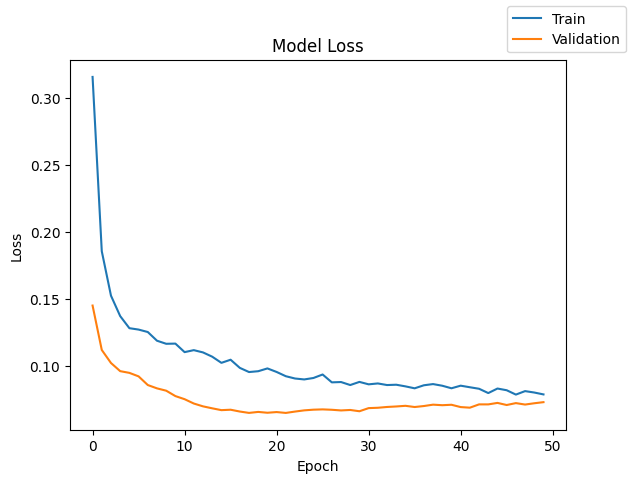

In [333]:
plot(history3,'loss')

In [334]:
evaluation_results.loc[3] = ['Model 3', '2', '[14, 7]', 'ReLU', 'Dropout(0.3)', epochs, batch_size, history3.history["loss"][-1], history3.history["binary_accuracy"][-1], history3.history["precision"][-1], history3.history["recall"][-1], 2 * (history3.history["precision"][-1] * history3.history["recall"][-1]) / (history3.history["precision"][-1] + history3.history["recall"][-1] + 1e-7), history3.history["val_loss"][-1], history3.history["val_binary_accuracy"][-1], history3.history["val_precision"][-1], history3.history["val_recall"][-1], 2 * (history3.history["val_precision"][-1] * history3.history["val_recall"][-1]) / (history3.history["val_precision"][-1] + history3.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630
3,Model 3,2,"[14, 7]",ReLU,Dropout(0.3),50,64,0.079062,0.979235,0.914326,0.690350,0.786707,0.073297,0.987333,0.970803,0.796407,0.875000


***Observations***
* Adding $30\%$ Dropout caused performance to tank, particularly in Recall
* Dropout is meant to prevent overfitting, but because our network is already quite small, it actually caused underfitting

## Model 4

***As we have are dealing with an imbalance in class distribution, we should also be using class weights to allow the model to give proportionally more importance to the minority class***

In [335]:
# Calculate class weights for imbalanced dataset
cw = (y_train.shape[0]) / np.bincount(y_train.astype(int)) # Convert y_train to integers

# Create a dictionary mapping class indices to their respective class weights
cw_dict = {}
for i in range(cw.shape[0]):
    cw_dict[i] = cw[i]

cw_dict

{0: np.float64(1.058728280500716), 1: np.float64(18.027571580063626)}

In [336]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [337]:
#Initializing the neural network
model4 = Sequential()
model4.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model4.add(Dropout(0.3)) # Dropout layer to prevent overfitting
model4.add(Dense(7, activation='relu'))
model4.add(Dropout(0.3))
model4.add(Dense(1, activation='sigmoid'))

In [338]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model4.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [339]:
epochs = 50
batch_size = 64

In [340]:
start = time.time()
history4 = model4.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - binary_accuracy: 0.7538 - loss: 1.7978 - precision: 0.0880 - recall: 0.3669 - val_binary_accuracy: 0.7957 - val_loss: 0.4866 - val_precision: 0.1850 - val_recall: 0.7844
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.7728 - loss: 1.0977 - precision: 0.1570 - recall: 0.7084 - val_binary_accuracy: 0.8300 - val_loss: 0.4129 - val_precision: 0.2316 - val_recall: 0.8862
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.7989 - loss: 0.9034 - precision: 0.1895 - recall: 0.8006 - val_binary_accuracy: 0.8580 - val_loss: 0.3817 - val_precision: 0.2692 - val_recall: 0.9042
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8258 - loss: 0.8389 - precision: 0.2176 - recall: 0.8250 - val_binary_accuracy: 0.8807 - val_loss: 0.3613 - val_precision: 0.3047 - val_recall: 0.8922
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8449 - loss: 0.7872 - precision

In [341]:
print("Time taken in seconds ",end-start)

Time taken in seconds  49.38945031166077


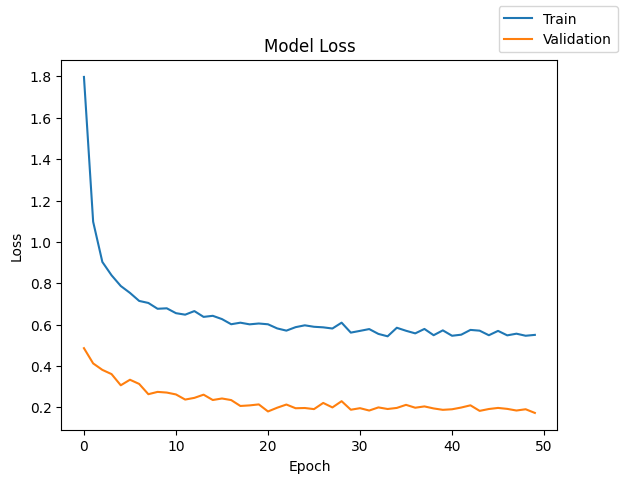

In [342]:
plot(history4,'loss')

In [343]:
evaluation_results.loc[4] = ['Model 4', '2', '[14, 7]', 'ReLU', 'class weights', epochs, batch_size, history4.history["loss"][-1], history4.history["binary_accuracy"][-1], history4.history["precision"][-1], history4.history["recall"][-1], 2 * (history4.history["precision"][-1] * history4.history["recall"][-1]) / (history4.history["precision"][-1] + history4.history["recall"][-1] + 1e-7), history4.history["val_loss"][-1], history4.history["val_binary_accuracy"][-1], history4.history["val_precision"][-1], history4.history["val_recall"][-1], 2 * (history4.history["val_precision"][-1] * history4.history["val_recall"][-1]) / (history4.history["val_precision"][-1] + history4.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630
3,Model 3,2,"[14, 7]",ReLU,Dropout(0.3),50,64,0.079062,0.979235,0.914326,0.690350,0.786707,0.073297,0.987333,0.970803,0.796407,0.875000
4,Model 4,2,"[14, 7]",ReLU,class weights,50,64,0.550857,0.954824,0.559809,0.868505,0.680798,0.173617,0.974000,0.717073,0.880240,0.790323


***Observations***
* By telling the model that Class 1 is "more important," we forced it to prioritize Recall ($0.88$)
* It successfully caught more of Class 1, but its Precision dropped to $0.71$. This means nearly $30\%$ of its "positive" predictions are actually False Alarms

## Model 5

***Add Batch Normalization to stabilize learning***

In [344]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [345]:
#Initializing the neural network
model5 = Sequential()
model5.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model5.add(BatchNormalization()) # Stabilizes learning
model5.add(Dense(7, activation='relu'))
model5.add(BatchNormalization())
model5.add(Dense(1, activation='sigmoid'))

In [346]:
model5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771 (3.01 KB)

 Trainable params: 729 (2.85 KB)

 Non-trainable params: 42 (168.00 B)

In [347]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model5.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [348]:
epochs = 50
batch_size = 64

In [349]:
start = time.time()
history5 = model5.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - binary_accuracy: 0.6888 - loss: 0.9441 - precision: 0.1360 - recall: 0.8611 - val_binary_accuracy: 0.8997 - val_loss: 0.3256 - val_precision: 0.3427 - val_recall: 0.8743
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.8957 - loss: 0.6313 - precision: 0.3312 - recall: 0.8632 - val_binary_accuracy: 0.9333 - val_loss: 0.2528 - val_precision: 0.4486 - val_recall: 0.8623
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - binary_accuracy: 0.9282 - loss: 0.5695 - precision: 0.4271 - recall: 0.8600 - val_binary_accuracy: 0.9450 - val_loss: 0.2212 - val_precision: 0.5034 - val_recall: 0.8743
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9345 - loss: 0.5337 - precision: 0.4525 - recall: 0.8643 - val_binary_accuracy: 0.9633 - val_loss: 0.1901 - val_precision: 0.6213 - val_recall: 0.8743
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9425 - loss: 0.5106 - precision

In [350]:
print("Time taken in seconds ",end-start)

Time taken in seconds  54.56040120124817


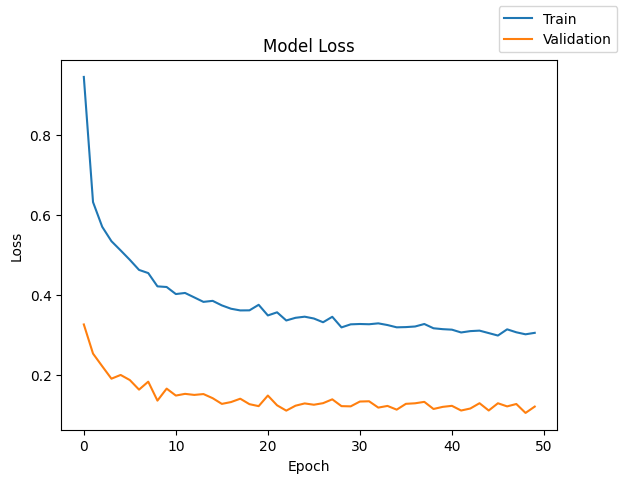

In [351]:
plot(history5,'loss')

In [352]:
evaluation_results.loc[5] = ['Model 5', '2', '[14, 7]', 'ReLU', 'BatchNormalization()', epochs, batch_size, history5.history["loss"][-1], history5.history["binary_accuracy"][-1], history5.history["precision"][-1], history5.history["recall"][-1], 2 * (history5.history["precision"][-1] * history5.history["recall"][-1]) / (history5.history["precision"][-1] + history5.history["recall"][-1] + 1e-7), history5.history["val_loss"][-1], history5.history["val_binary_accuracy"][-1], history5.history["val_precision"][-1], history5.history["val_recall"][-1], 2 * (history5.history["val_precision"][-1] * history5.history["val_recall"][-1]) / (history5.history["val_precision"][-1] + history5.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630
3,Model 3,2,"[14, 7]",ReLU,Dropout(0.3),50,64,0.079062,0.979235,0.914326,0.690350,0.786707,0.073297,0.987333,0.970803,0.796407,0.875000
4,Model 4,2,"[14, 7]",ReLU,class weights,50,64,0.550857,0.954824,0.559809,0.868505,0.680798,0.173617,0.974000,0.717073,0.880240,0.790323
5,Model 5,2,"[14, 7]",ReLU,BatchNormalization(),50,64,0.304670,0.973588,0.700813,0.914104,0.793373,0.120399,0.978000,0.751244,0.904192,0.820652


***Observations***
* Batch Normalization provided the highest Validation Recall ($0.904$) of any model
* Batch Norm stabilized the training process, allowing the model to "dig deeper" into the minority class data. However, like Model 4, it sacrificed Precision to get there

## Model 6

***Adding one more hidden layer***

In [353]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [354]:
#Initializing the neural network
model6 = Sequential()
model6.add(Dense(14, activation='relu', input_shape=(X_train.shape[1],)))
model6.add(BatchNormalization()) # Stabilizes learning
model6.add(Dense(7, activation='relu'))
model6.add(BatchNormalization())
model6.add(Dense(7, activation='relu'))
model6.add(BatchNormalization())
model6.add(Dense(1, activation='sigmoid'))

In [355]:
model6.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855 (3.34 KB)

 Trainable params: 799 (3.12 KB)

 Non-trainable params: 56 (224.00 B)

In [356]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model6.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [357]:
epochs = 50
batch_size = 64
start = time.time()
history6 = model6.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - binary_accuracy: 0.7245 - loss: 1.0002 - precision: 0.1461 - recall: 0.8187 - val_binary_accuracy: 0.9160 - val_loss: 0.3984 - val_precision: 0.3867 - val_recall: 0.8683
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - binary_accuracy: 0.8914 - loss: 0.6281 - precision: 0.3245 - recall: 0.8865 - val_binary_accuracy: 0.9437 - val_loss: 0.2592 - val_precision: 0.4967 - val_recall: 0.8922
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9314 - loss: 0.5187 - precision: 0.4412 - recall: 0.8876 - val_binary_accuracy: 0.9657 - val_loss: 0.1943 - val_precision: 0.6368 - val_recall: 0.8922
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9492 - loss: 0.4750 - precision: 0.5252 - recall: 0.8844 - val_binary_accuracy: 0.9723 - val_loss: 0.1675 - val_precision: 0.6963 - val_recall: 0.8922
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9535 - loss: 0.4539 - precision

In [358]:
print("Time taken in seconds ",end-start)

Time taken in seconds  59.90924143791199


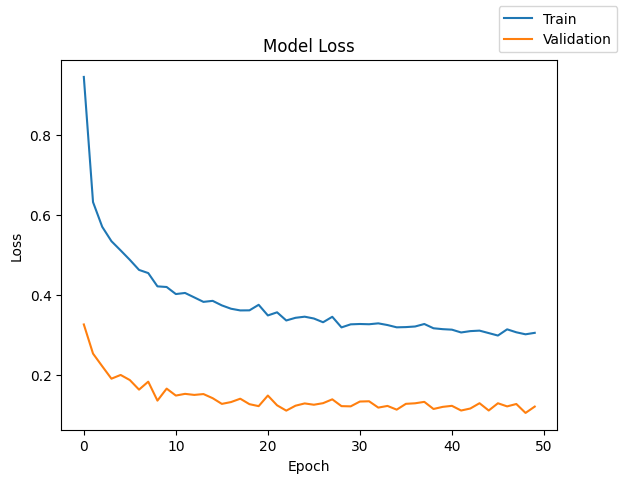

In [359]:
plot(history5,'loss')

In [360]:
evaluation_results.loc[6] = ['Model 6', '3', '[14, 7, 7]', 'ReLU', '3 hidden layers', epochs, batch_size, history6.history["loss"][-1], history6.history["binary_accuracy"][-1], history6.history["precision"][-1], history6.history["recall"][-1], 2 * (history6.history["precision"][-1] * history6.history["recall"][-1]) / (history6.history["precision"][-1] + history6.history["recall"][-1] + 1e-7), history6.history["val_loss"][-1], history6.history["val_binary_accuracy"][-1], history6.history["val_precision"][-1], history6.history["val_recall"][-1], 2 * (history6.history["val_precision"][-1] * history6.history["val_recall"][-1]) / (history6.history["val_precision"][-1] + history6.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630
3,Model 3,2,"[14, 7]",ReLU,Dropout(0.3),50,64,0.079062,0.979235,0.914326,0.690350,0.786707,0.073297,0.987333,0.970803,0.796407,0.875000
4,Model 4,2,"[14, 7]",ReLU,class weights,50,64,0.550857,0.954824,0.559809,0.868505,0.680798,0.173617,0.974000,0.717073,0.880240,0.790323
5,Model 5,2,"[14, 7]",ReLU,BatchNormalization(),50,64,0.304670,0.973588,0.700813,0.914104,0.793373,0.120399,0.978000,0.751244,0.904192,0.820652
6,Model 6,3,"[14, 7, 7]",ReLU,3 hidden layers,50,64,0.303594,0.975176,0.715111,0.918346,0.804085,0.112706,0.979667,0.770408,0.904192,0.831956


***Observations***
* Adding a 3rd hidden layer ($[14, 7, 7]$) did not help
* The performance of the model is nearly identical to Model 5. This tells us that architecture depth is not your bottleneck anymore. Adding more layers just adds complexity without better results

## Model 7

***He normal (kernel_initializer='he_normal') for the weights of the hidden layers***

In [361]:
# clears the current Keras session, resetting all layers and models previously created, freeing up memory and resources.
tf.keras.backend.clear_session()

In [365]:
#Initializing the neural network
model7 = Sequential()
model7.add(Dense(14, activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)))
model7.add(BatchNormalization()) # Stabilizes learning
model7.add(Dense(7, activation='relu', kernel_initializer='he_normal'))
model7.add(BatchNormalization())
model7.add(Dense(7, activation='relu', kernel_initializer='he_normal'))
model7.add(BatchNormalization())
model7.add(Dense(1, activation='sigmoid'))

In [366]:
model7.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 14)             │           574 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │           105 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7)              │            28 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 855 (3.34 KB)

 Trainable params: 799 (3.12 KB)

 Non-trainable params: 56 (224.00 B)

In [367]:
optimizer = 'adam'   # defining SGD as the optimizer to be used
loss = 'binary_crossentropy'
model7.compile(loss=loss, optimizer=optimizer, metrics=[tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()])

In [368]:
epochs = 50
batch_size = 64
start = time.time()
history7 = model7.fit(X_train, y_train, validation_data=(X_val,y_val) , batch_size=batch_size, epochs=epochs, class_weight=cw_dict)
end = time.time()

Epoch 1/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - binary_accuracy: 0.7158 - loss: 1.0612 - precision: 0.1407 - recall: 0.8070 - val_binary_accuracy: 0.8910 - val_loss: 0.3917 - val_precision: 0.3182 - val_recall: 0.8383
Epoch 2/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - binary_accuracy: 0.8998 - loss: 0.6565 - precision: 0.3411 - recall: 0.8664 - val_binary_accuracy: 0.9470 - val_loss: 0.2557 - val_precision: 0.5142 - val_recall: 0.8683
Epoch 3/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.9321 - loss: 0.5597 - precision: 0.4431 - recall: 0.8759 - val_binary_accuracy: 0.9587 - val_loss: 0.2072 - val_precision: 0.5870 - val_recall: 0.8683
Epoch 4/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9415 - loss: 0.5154 - precision: 0.4848 - recall: 0.8791 - val_binary_accuracy: 0.9600 - val_loss: 0.1909 - val_precision: 0.5967 - val_recall: 0.8683
Epoch 5/50
266/266 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.9495 - loss: 0.4882 - precision

In [369]:
print("Time taken in seconds ",end-start)

Time taken in seconds  58.62565016746521


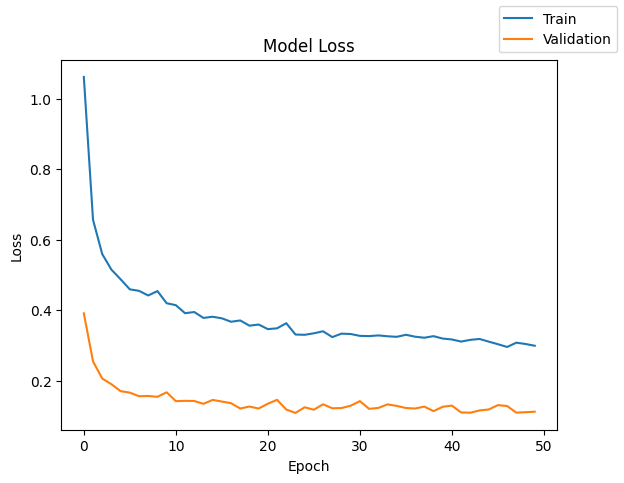

In [370]:
plot(history7,'loss')

In [371]:
evaluation_results.loc[7] = ['Model 7', '3', '[14, 7, 7]', 'ReLU', "kernel_initializer=\'he_normal\'", epochs, batch_size, history7.history["loss"][-1], history7.history["binary_accuracy"][-1], history7.history["precision"][-1], history7.history["recall"][-1], 2 * (history7.history["precision"][-1] * history7.history["recall"][-1]) / (history7.history["precision"][-1] + history7.history["recall"][-1] + 1e-7), history7.history["val_loss"][-1], history7.history["val_binary_accuracy"][-1], history7.history["val_precision"][-1], history7.history["val_recall"][-1], 2 * (history7.history["val_precision"][-1] * history7.history["val_recall"][-1]) / (history7.history["val_precision"][-1] + history7.history["val_recall"][-1] + 1e-7)]
evaluation_results

,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630
3,Model 3,2,"[14, 7]",ReLU,Dropout(0.3),50,64,0.079062,0.979235,0.914326,0.690350,0.786707,0.073297,0.987333,0.970803,0.796407,0.875000
4,Model 4,2,"[14, 7]",ReLU,class weights,50,64,0.550857,0.954824,0.559809,0.868505,0.680798,0.173617,0.974000,0.717073,0.880240,0.790323
5,Model 5,2,"[14, 7]",ReLU,BatchNormalization(),50,64,0.304670,0.973588,0.700813,0.914104,0.793373,0.120399,0.978000,0.751244,0.904192,0.820652
6,Model 6,3,"[14, 7, 7]",ReLU,3 hidden layers,50,64,0.303594,0.975176,0.715111,0.918346,0.804085,0.112706,0.979667,0.770408,0.904192,0.831956
7,Model 7,3,"[14, 7, 7]",ReLU,kernel_initializer='he_normal',50,64,0.299966,0.976471,0.731458,0.909862,0.810964,0.113202,0.977333,0.748744,0.892216,0.814208


***Observations***
* "He Normal" initialization did not help
* Performed worse than model 6 in all metrics

# **Model Performance Comparison and Final Model Selection**

Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.

In [372]:
evaluation_results


,Model,# hidden layers,# neurons hidden layer,activation function hidden layer,configuration,# epochs,batch size,Train_Loss,Train_Accuracy,Train_Precision,Train_Recall,Train_F1,Val_Loss,Val_Accuracy,Val_Precision,Val_Recall,Val_F1
0,Model 0,1,[7],ReLU,baseline,50,64,0.059472,0.986706,0.964981,0.788971,0.868145,0.067529,0.985667,0.936620,0.796407,0.860841
1,Model 1,2,"[14, 7]",ReLU,2 hidden layers,50,64,0.047338,0.990824,0.981640,0.850477,0.911364,0.058007,0.988667,0.958621,0.832335,0.891026
2,Model 2,2,"[14, 7]",ReLU,optimizer=adam,50,64,0.034138,0.994118,0.988412,0.904560,0.944629,0.072790,0.991667,0.967105,0.880240,0.921630
3,Model 3,2,"[14, 7]",ReLU,Dropout(0.3),50,64,0.079062,0.979235,0.914326,0.690350,0.786707,0.073297,0.987333,0.970803,0.796407,0.875000
4,Model 4,2,"[14, 7]",ReLU,class weights,50,64,0.550857,0.954824,0.559809,0.868505,0.680798,0.173617,0.974000,0.717073,0.880240,0.790323
5,Model 5,2,"[14, 7]",ReLU,BatchNormalization(),50,64,0.304670,0.973588,0.700813,0.914104,0.793373,0.120399,0.978000,0.751244,0.904192,0.820652
6,Model 6,3,"[14, 7, 7]",ReLU,3 hidden layers,50,64,0.303594,0.975176,0.715111,0.918346,0.804085,0.112706,0.979667,0.770408,0.904192,0.831956
7,Model 7,3,"[14, 7, 7]",ReLU,kernel_initializer='he_normal',50,64,0.299966,0.976471,0.731458,0.909862,0.810964,0.113202,0.977333,0.748744,0.892216,0.814208


***Observations***
* ***Model 2 is the strongest overall model***. By switching to the Adam optimizer, we saw a significant jump across all metrics
* Model 2 provides the best balance F1(0.9216), the gap between Training and validation metrics is small- generalizes well without heavy overfitting
* With a Val_Precision of 0.967, Model 2 incredibly reliable when it predicts a positive class, while still maintaining a strong Recall (0.88)
* Model 5 (Batch Normalization): Achieved the highest Val_Recall (0.904). This means it caught over 90% of the minority class. As Recall went up, Precision dropped (~0.75). These models are "trigger-happy"—they catch more positives but also create more false alarms.
* ***Impact of Architecture*** Adding that second layer improved the F1-score from 0.86 to 0.89. The extra complexity helped the model learn the nuances of the minority class.Moving to 3 layers didn't actually help performance over Model 2. In fact, the precision dropped significantly.
* ***Regularization Impact*** Model 3 (Dropout 0.3): The Train_Recall (0.69) is much lower than other models. It is too aggressive and causing it to under-perform on the minority class
* ***Lets pick Model2*** as it has the best overall balance (Highest F1-score and best precision-recall mix) with relatively good performance and simplicity


Now, let's check the performance of the final model on the test set.

In [373]:
y_test_pred = model2.predict(X_test)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [374]:
print("Classification Report - Test data",end="\n\n")
cr = classification_report(y_test,y_test_pred>0.5)
print(cr)

Classification Report - Test data

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      4718
           1       0.97      0.87      0.92       282

    accuracy                           0.99      5000
   macro avg       0.98      0.93      0.96      5000
weighted avg       0.99      0.99      0.99      5000



***Observations***


*   We have 4,718 instances of Class 0 and only 282 of Class 1. This means Class 0 represents about 94% of your data
*   Class 0: The model is nearly perfect here ($1.00$ recall and $0.99$ precision)
*   Class 1: The model is still very strong.
*   ***Precision (0.97):*** When the model predicts Class 1, it is right 97% of the time. We have very few "false alarms."
* ***Recall (0.87):*** The model is catching 87% of all actual Class 1 cases. It is missing about 13% of them (false negatives).

* ***F1-Score (0.92):*** This is a great balance between precision and recall. For a minority class, a 0.92 F1-score is generally considered excellent.



# **Actionable Insights and Recommendations**


*   The dataset is highly imbalanced, with Class 1 (the minority class) representing only about 5.6% of the total data—this means the "cost" of a mistake is rarely equal
*  Model 2 (Adam Optimizer) is the most efficient "All-Rounder." It provides the highest reliability (Precision) while maintaining strong coverage (Recall)
*  Model 5 (Batch Normalization) is our best "Safety First" model. It is more aggressive at catching Class 1 cases, but at the cost of more false alarms.
*  While Recall is the metric we are mostly interested in, having a model with a lot of false positives also causes unwanted downtime and cost to the business
*  Models 6 and 7 (3 hidden layers) showed diminishing returns. Adding complexity (more layers) actually lowered your Precision without a significant boost in Recall. For this specific problem, a 2-layer architecture appears to be the "sweet spot" for generalization
*  The jump from Model 1 to Model 2 shows that Optimization Strategy mattered more than Architecture Depth. The Adam optimizer's ability to handle sparse gradients is likely why it performed so well on your minority class compared to the standard baseline
